# EDA

### Índice
1. Introducción
2. Carga del dataset
3. Información general del dataset
4. Funciones auxiliares 
5. Análisis de variables numéricas
6. Análisis de variables categóricas 
7. Análisis de la variable objetivo (y)
8. Perfil sociodemográfico del cliente 
    - Edad
    - Trabajo
    - Estado civil
    - Educación 
    - Ingresos 
    - Entorno familiar 
9. Comportamiento del cliente y dinámica de la campaña 
    - Duración de la llamada
    - Número de leads de campaña 
    - Leads previos 
    - Resultado previo de campaña 
    - Canal de contacto 
    - Comportamiento digital 
    - Antigüedad del cliente 
10. Contexto económico 
11. Análisis temporal
12. Relación global de con la varible objetivo 
13. Correlaciones entre variables numéricas 
14. Conclusiones finales
15. Ranking de las variables más relacionadas con y 
16. Automatización con POO
----------------------------------------------------------

1. Introducción 

Con este análisis vamos a contestar a la pregunta:
-  ¿Qué características tienen los clientes que sí contratan el depósito frente a los que no?

In [1]:
# Importamos las librerías usadas 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Configuración visual

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

---

2. Carga del dataset

In [3]:
df_bank_marketing=pd.read_csv("C:/Users/patri/OneDrive/Documentos/Proyecto-EDA/data/processed/bank_marketing.csv") 
df_bank_marketing.head()

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_,age_missing,euribor_missing,contact_year,contact_month,contact_weekday,was_contacted_before,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,Family_size,Has_kid,Has_teens,Customer_year,Customer_month,Customer_tenure_years,tenure_at_contact_days
0,38.0,housemaid,married,basic.4y,0.0,0.0,0.0,telephone,261,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,2019-08-02,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,1,0,2019.0,8.0,Friday,0,161770,1,0,2012-04-04,29,1,1,0,2012,4,14.0,7.0
1,57.0,services,married,high.school,unknown,0.0,0.0,telephone,149,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,2016-09-14,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,0,1,2016.0,9.0,Wednesday,0,85477,1,1,2012-12-30,7,2,1,1,2012,12,13.0,4.0
2,37.0,services,married,high.school,0.0,1.0,0.0,telephone,226,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,2019-02-15,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b,0,0,2019.0,2.0,Friday,0,147233,1,1,2012-02-02,5,2,1,1,2012,2,14.0,7.0
3,40.0,admin.,married,basic.6y,0.0,0.0,0.0,telephone,151,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,2015-11-29,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e,0,1,2015.0,11.0,Sunday,0,121393,1,2,2012-12-21,29,3,1,1,2012,12,13.0,3.0
4,56.0,services,married,high.school,0.0,0.0,1.0,telephone,307,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,2017-01-29,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,0,1,2017.0,1.0,Sunday,0,63164,1,2,2012-06-20,20,3,1,1,2012,6,14.0,5.0


In [4]:
# Copia de trabajo
data = df_bank_marketing.copy()

print("Dataset cargado correctamente")
print(f"Filas: {data.shape[0]}")
print(f"Columnas: {data.shape[1]}")

Dataset cargado correctamente
Filas: 42752
Columnas: 41


---

3. Información general del dataset

In [5]:
data.head()

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_,age_missing,euribor_missing,contact_year,contact_month,contact_weekday,was_contacted_before,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,Family_size,Has_kid,Has_teens,Customer_year,Customer_month,Customer_tenure_years,tenure_at_contact_days
0,38.0,housemaid,married,basic.4y,0.0,0.0,0.0,telephone,261,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,2019-08-02,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,1,0,2019.0,8.0,Friday,0,161770,1,0,2012-04-04,29,1,1,0,2012,4,14.0,7.0
1,57.0,services,married,high.school,unknown,0.0,0.0,telephone,149,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,2016-09-14,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,0,1,2016.0,9.0,Wednesday,0,85477,1,1,2012-12-30,7,2,1,1,2012,12,13.0,4.0
2,37.0,services,married,high.school,0.0,1.0,0.0,telephone,226,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,2019-02-15,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b,0,0,2019.0,2.0,Friday,0,147233,1,1,2012-02-02,5,2,1,1,2012,2,14.0,7.0
3,40.0,admin.,married,basic.6y,0.0,0.0,0.0,telephone,151,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,2015-11-29,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e,0,1,2015.0,11.0,Sunday,0,121393,1,2,2012-12-21,29,3,1,1,2012,12,13.0,3.0
4,56.0,services,married,high.school,0.0,0.0,1.0,telephone,307,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,2017-01-29,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,0,1,2017.0,1.0,Sunday,0,63164,1,2,2012-06-20,20,3,1,1,2012,6,14.0,5.0


In [6]:
data.tail()

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_,age_missing,euribor_missing,contact_year,contact_month,contact_weekday,was_contacted_before,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,Family_size,Has_kid,Has_teens,Customer_year,Customer_month,Customer_tenure_years,tenure_at_contact_days
42747,38.0,admin.,married,university.degree,0.0,0.0,0.0,cellular,618,2,NaN,0,nonexistent,1.4,93.444,-36.1,4.857,5228.1,1,2015-10-13,38.147,-105.582,4eed05de-2a98-4227-b488-32122009b638,1,1,2015.0,10.0,Tuesday,0,68672,0,2,2014-03-08,22,2,0,1,2014,3,12.0,2.0
42748,34.0,technician,married,professional.course,0.0,1.0,1.0,cellular,42,7,NaN,0,nonexistent,-0.1,93.200,-42.0,4.857,5195.8,0,2018-03-17,49.235,-112.201,0f0aca88-4088-4fe2-905f-44fb675d9493,0,1,2018.0,3.0,Saturday,0,73578,0,2,2014-03-11,26,2,0,1,2014,3,12.0,4.0
42749,38.0,blue-collar,single,basic.6y,0.0,1.0,0.0,cellular,391,2,NaN,0,nonexistent,1.4,93.918,-42.7,4.857,5228.1,0,2016-09-15,40.679,-120.015,cadadd4b-7ee5-4019-b13a-ca01bb67ca5b,1,1,2016.0,9.0,Thursday,0,9816,2,2,2014-09-18,31,4,1,1,2014,9,11.0,2.0
42750,38.0,admin.,married,university.degree,unknown,0.0,0.0,cellular,674,3,NaN,0,nonexistent,1.4,93.918,-42.7,4.958,5228.1,0,2019-09-23,27.772,-117.518,5f432048-d515-4bb5-9c94-62db451f88d4,1,0,2019.0,9.0,Monday,0,156980,1,2,2014-05-17,7,3,1,1,2014,5,12.0,5.0
42751,38.0,unemployed,single,university.degree,0.0,0.0,1.0,cellular,104,2,NaN,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0,2019-11-06,41.146,-105.026,993bbbd6-4dbc-4a40-a408-f91f8462bee6,1,0,2019.0,11.0,Wednesday,0,139820,0,0,2014-09-29,1,0,0,0,2014,9,11.0,5.0


In [7]:
data.shape

(42752, 41)

In [ ]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 42752 entries, 0 to 42751
Data columns (total 41 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     42752 non-null  float64
 1   job                     42752 non-null  str    
 2   marital                 42752 non-null  str    
 3   education               42752 non-null  str    
 4   default                 42752 non-null  str    
 5   housing                 42752 non-null  str    
 6   loan                    42752 non-null  str    
 7   contact                 42752 non-null  str    
 8   duration                42752 non-null  int64  
 9   campaign                42752 non-null  int64  
 10  pdays                   1577 non-null   float64
 11  previous                42752 non-null  int64  
 12  poutcome                42752 non-null  str    
 13  emp.var.rate            42752 non-null  float64
 14  cons.price.idx          42752 non-null  float64
 

In [9]:
data.nunique()

age                          78
job                          12
marital                       4
education                     8
default                       3
housing                       3
loan                          3
contact                       2
duration                   1540
campaign                     42
pdays                        26
previous                      8
poutcome                      3
emp.var.rate                 10
cons.price.idx               26
cons.conf.idx                26
euribor3m                   308
nr.employed                  11
y                             2
date                       1825
latitude                  20447
longitude                 30329
id_                       42752
age_missing                   2
euribor_missing               2
contact_year                  5
contact_month                12
contact_weekday               7
was_contacted_before          2
Income                    37977
Kidhome                       3
Teenhome

In [10]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,42752.0,39.745018,9.822489,17.000,33.000,38.000,46.000,98.000
duration,42752.0,257.766186,258.778698,0.000,102.000,179.000,319.000,4918.000
campaign,42752.0,2.566383,2.770606,1.000,1.000,2.000,3.000,56.000
pdays,1577.0,6.076728,3.873943,0.000,3.000,6.000,7.000,27.000
previous,42752.0,0.174237,0.497828,0.000,0.000,0.000,0.000,7.000
emp.var.rate,42752.0,0.077330,1.573703,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,42752.0,93.576226,0.576815,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,42752.0,-40.510100,4.637412,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,42752.0,3.883822,1.620777,0.634,1.479,4.857,4.959,5.045
nr.employed,42752.0,5166.866537,72.392792,4963.600,5099.100,5191.000,5228.100,5228.100


In [11]:
data.describe(include="object").T

C:\Users\patri\AppData\Local\Temp\ipykernel_4896\2469029036.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include="object").T


,count,unique,top,freq
job,42752,12,admin.,10802
marital,42752,4,married,25840
education,42752,8,university.degree,12642
default,42752,3,0.0,33810
housing,42752,3,1.0,22367
loan,42752,3,0.0,35244
contact,42752,2,cellular,27232
poutcome,42752,3,nonexistent,36883
date,42752,1825,2018-02-28,95
id_,42752,42752,089b39d8-e4d0-461b-87d4-814d71e0e079,1


In [12]:
missing_summary = pd.DataFrame({
    "missing_values": data.isna().sum(),
    "missing_pct": (data.isna().sum() / len(data) * 100).round(2)
}).sort_values(by="missing_values", ascending=False)

missing_summary[missing_summary["missing_values"] > 0]

,missing_values,missing_pct
pdays,41175,96.31


In [13]:
data.groupby("was_contacted_before")["pdays"].count()


was_contacted_before
0       0
1    1577
Name: pdays, dtype: int64

La variable pdays presenta un alto porcentaje de valores nulos. Sin embargo, estos valores no representan datos faltantes sino clientes que nunca habían sido contactados previamente. Durante la fase de limpieza se transformaron los valores artificiales (como 999) en NaN para reflejar correctamente esta situación.

---

4. Funciones auxiliares 

In [14]:
def plot_count(series, title, xlabel=None, rotation=0, order=None):
    plt.figure(figsize=(10, 5))
    sns.countplot(x=series, order=order)
    plt.title(title)
    plt.xlabel(xlabel if xlabel else series.name)
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()


def plot_hist(series, title, bins=30):
    plt.figure(figsize=(10, 5))
    sns.histplot(series.dropna(), bins=bins, kde=True)
    plt.title(title)
    plt.xlabel(series.name)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()


def plot_box_by_target(df, x_col, y_col, title):
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=x_col, y=y_col)
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()


def plot_target_rate_by_category(df, cat_col, target_col="y", order=None):
    rate = (
        df.groupby(cat_col)[target_col]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    if order is None:
        order = rate[cat_col]

    plt.figure(figsize=(10, 5))
    sns.barplot(data=rate, x=cat_col, y=target_col, order=order)
    plt.title(f"Tasa de suscripción por {cat_col}")
    plt.xlabel(cat_col)
    plt.ylabel("Tasa de suscripción")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    display(rate)


def target_summary_numeric(df, col, target_col="y"):
    summary = df.groupby(target_col)[col].agg(["mean", "median", "std", "min", "max"]).round(2)
    return summary


def target_rate_table(df, cat_col, target_col="y"):
    table = pd.crosstab(df[cat_col], df[target_col], normalize="index").round(4)
    table["conversion_rate"] = table[1]
    return table.sort_values("conversion_rate", ascending=False)

---

5. Análisis de variables numéricas 

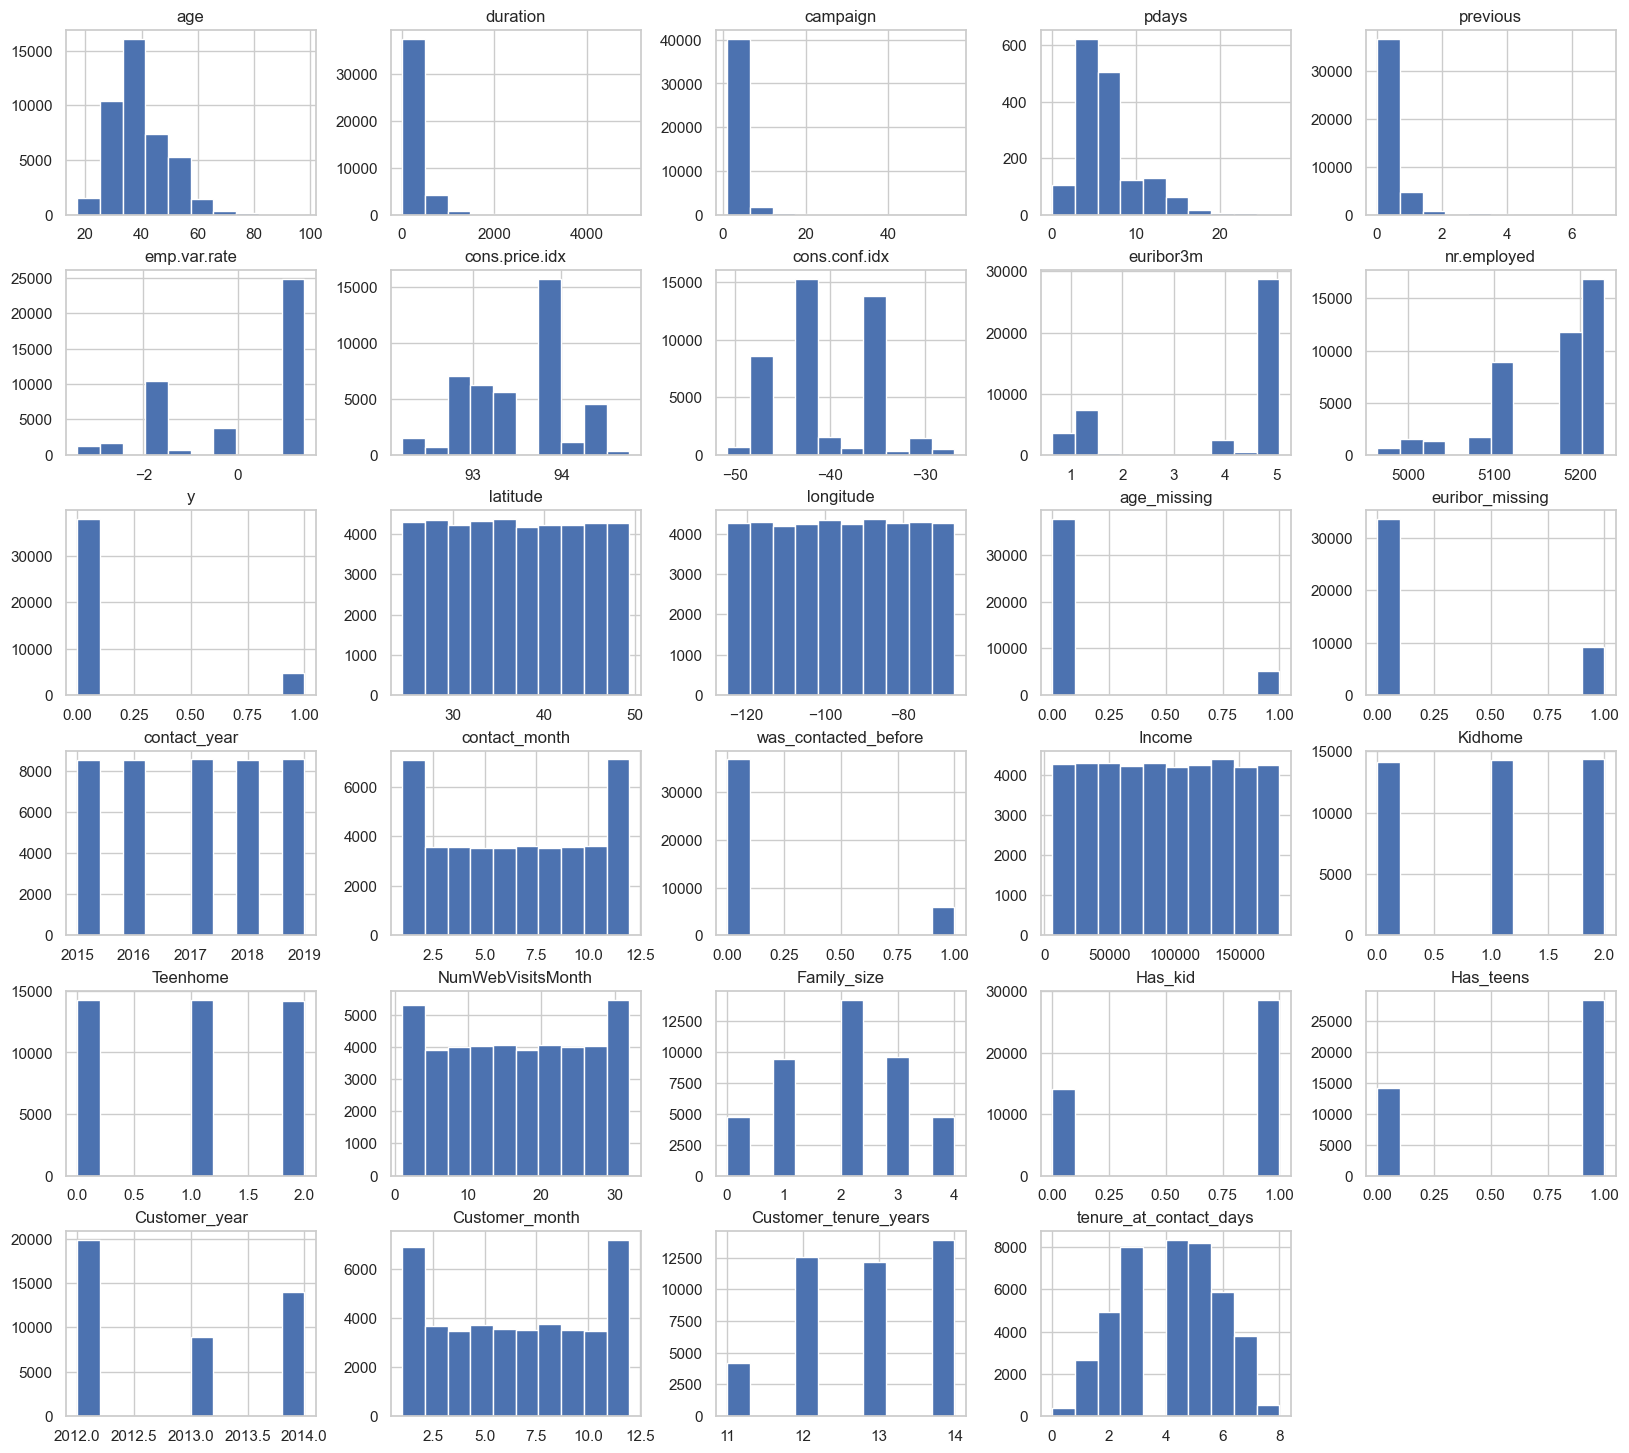

In [15]:
df_bank_marketing.hist(figsize=(20,18))
plt.show()

---

6. Análisis de variables categóricas

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'housemaid'),
  Text(1, 0, 'services'),
  Text(2, 0, 'admin.'),
  Text(3, 0, 'blue-collar'),
  Text(4, 0, 'technician'),
  Text(5, 0, 'retired'),
  Text(6, 0, 'management'),
  Text(7, 0, 'unemployed'),
  Text(8, 0, 'self-employed'),
  Text(9, 0, 'unknown'),
  Text(10, 0, 'entrepreneur'),
  Text(11, 0, 'student')])

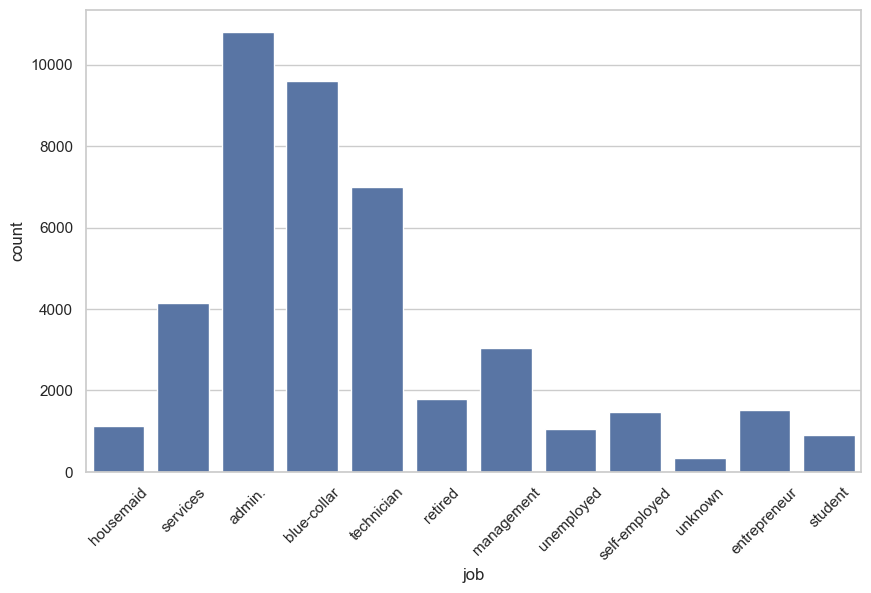

In [16]:
sns.countplot(data=df_bank_marketing, x="job")
plt.xticks(rotation=45)

In [17]:
(df_bank_marketing["job"].value_counts(normalize=True)*100).round(2)

job
admin.           25.27
blue-collar      22.47
technician       16.34
services          9.67
management        7.10
retired           4.17
entrepreneur      3.53
self-employed     3.47
housemaid         2.61
unemployed        2.48
student           2.10
unknown           0.80
Name: proportion, dtype: float64

---

7. Análisis de la variable objetivo


La variable objetivo del proyecto es `y`, que indica si el cliente ha suscrito (`1`) o no (`0`) el depósito ofrecido en la campaña de marketing. Analizar su distribución es fundamental, ya que condiciona la interpretación del resto del análisis.

In [18]:

data["y"].value_counts()

y
0    37941
1     4811
Name: count, dtype: int64

In [19]:
data["y"].value_counts(normalize=True).round(4) * 100

y
0    88.75
1    11.25
Name: proportion, dtype: float64

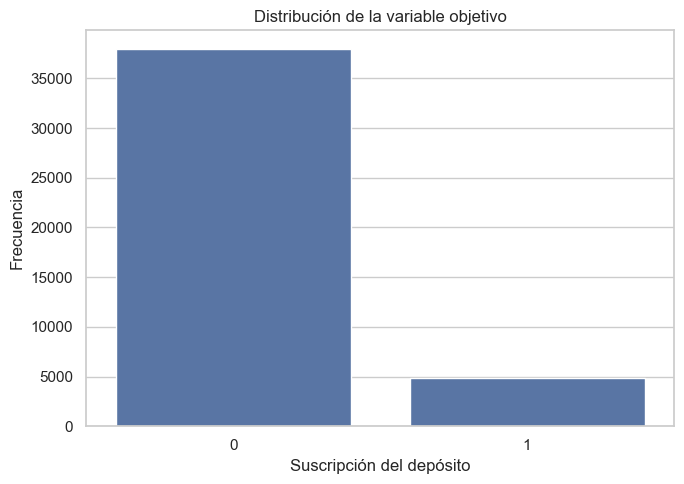

In [20]:
plt.figure(figsize=(7, 5))
sns.countplot(data=data, x="y")
plt.title("Distribución de la variable objetivo")
plt.xlabel("Suscripción del depósito")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

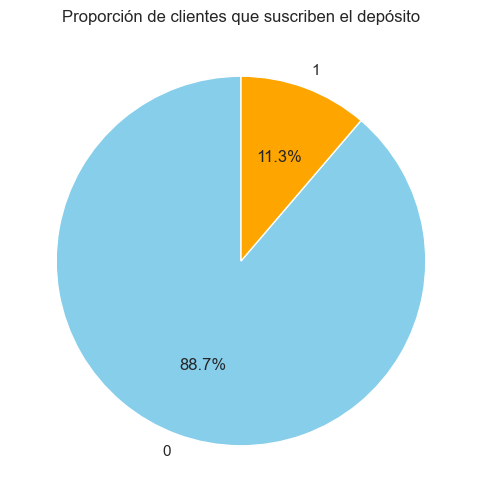

In [21]:
# Distribución de y 
plt.figure(figsize=(6,6))

data["y"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=["skyblue","orange"]
)

plt.title("Proporción de clientes que suscriben el depósito")
plt.ylabel("")
plt.show()

---

8. Perfil sociodemografico del cliente 

En esta sección se analiza cómo es la muestra desde el punto de vista demográfico y socioeconómico. El objetivo es describir el perfil general de los clientes y estudiar si variables como la edad, la ocupación, el estado civil, el nivel educativo o los ingresos presentan diferencias entre quienes suscriben y quienes no suscriben el depósito.

- Edad

In [22]:
data["age"].describe().round(2)

count    42752.00
mean        39.75
std          9.82
min         17.00
25%         33.00
50%         38.00
75%         46.00
max         98.00
Name: age, dtype: float64

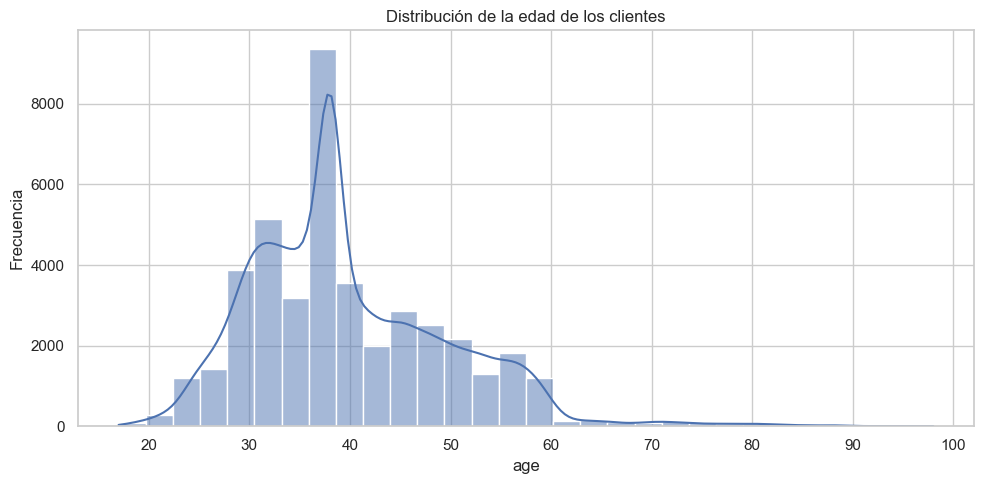

In [23]:
plot_hist(data["age"], "Distribución de la edad de los clientes", bins=30)

In [24]:
target_summary_numeric(data, "age")

,mean,median,std,min,max
y,,,,,
0,39.64,38.0,9.33,17.0,95.0
1,40.56,38.0,13.03,17.0,98.0


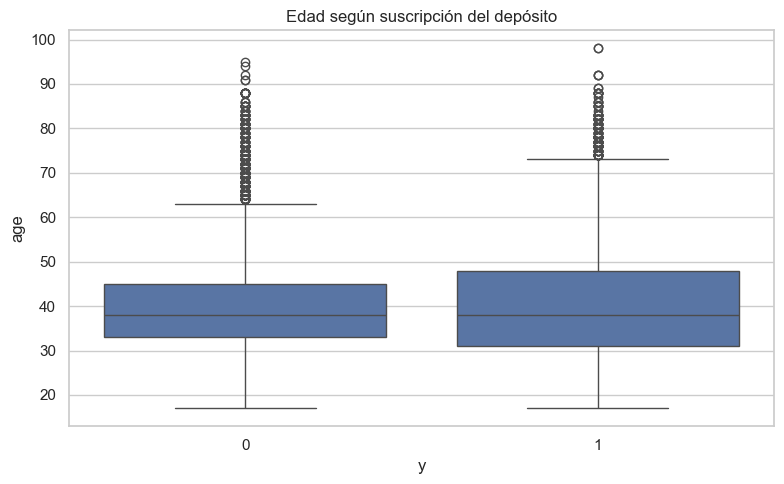

In [25]:
plot_box_by_target(data, "y", "age", "Edad según suscripción del depósito")

- Trabajo

In [26]:
data["job"].value_counts()

job
admin.           10802
blue-collar       9605
technician        6984
services          4135
management        3036
retired           1782
entrepreneur      1509
self-employed     1483
housemaid         1117
unemployed        1059
student            896
unknown            344
Name: count, dtype: int64

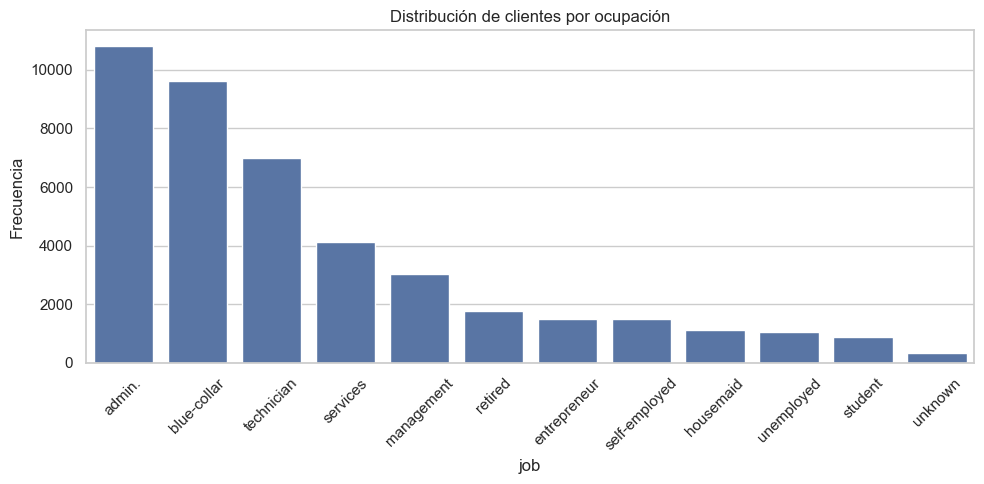

In [27]:
job_order = data["job"].value_counts().index
plot_count(data["job"], "Distribución de clientes por ocupación", rotation=45, order=job_order)

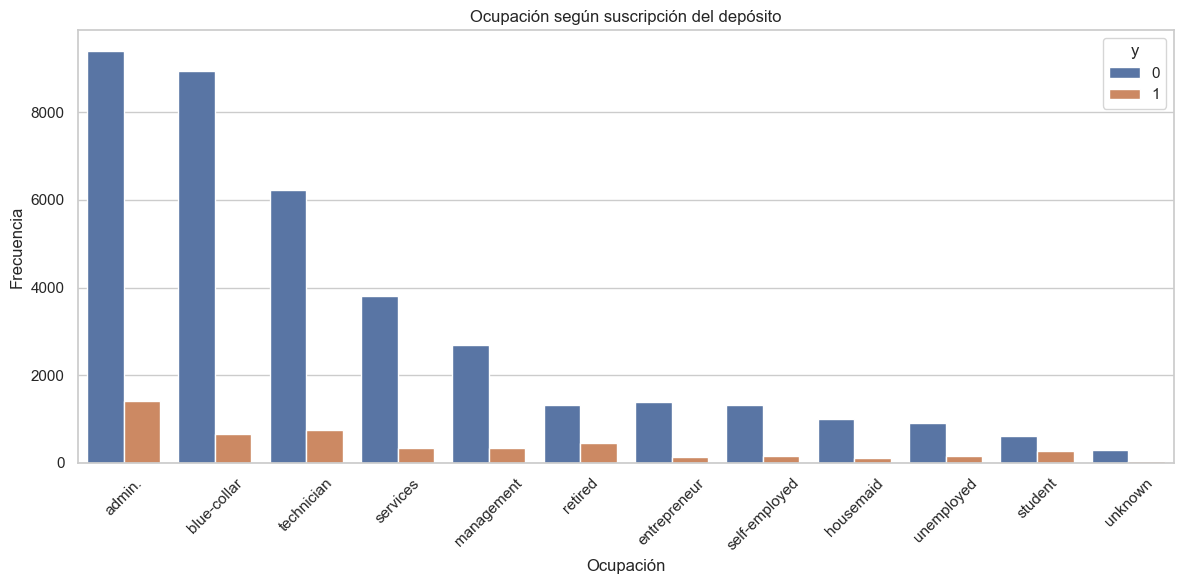

In [28]:
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x="job", hue="y", order=job_order)
plt.title("Ocupación según suscripción del depósito")
plt.xlabel("Ocupación")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
target_rate_table(data, "job")

y,0,1,conversion_rate
job,,,
student,0.6864,0.3136,0.3136
retired,0.7475,0.2525,0.2525
unemployed,0.8555,0.1445,0.1445
admin.,0.8702,0.1298,0.1298
unknown,0.8866,0.1134,0.1134
management,0.8887,0.1113,0.1113
self-employed,0.8914,0.1086,0.1086
technician,0.8916,0.1084,0.1084
housemaid,0.9006,0.0994,0.0994


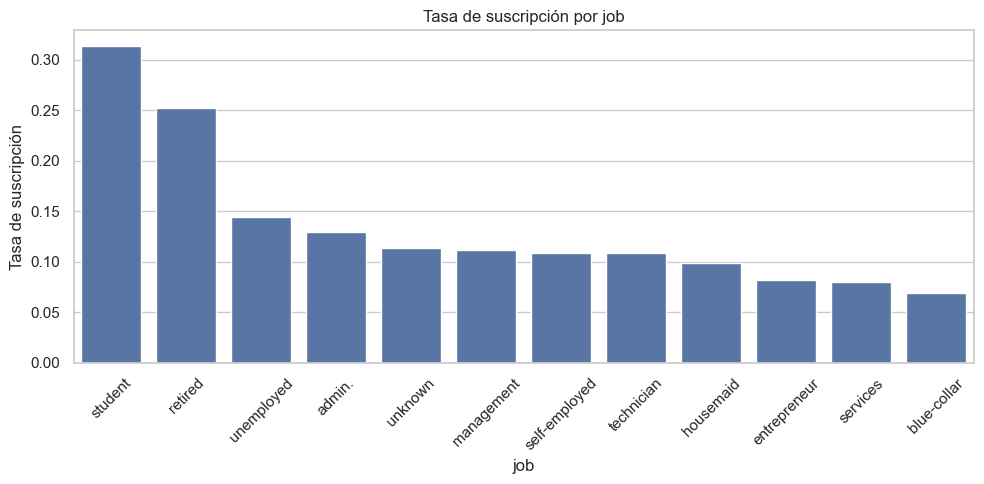

,job,y
0,student,0.313616
1,retired,0.252525
2,unemployed,0.144476
3,admin.,0.129791
4,unknown,0.113372
5,management,0.111331
6,self-employed,0.108564
7,technician,0.108391
8,housemaid,0.099373
9,entrepreneur,0.082174


In [30]:
plot_target_rate_by_category(data, "job")

- Estado civil

In [31]:
data["marital"].value_counts()

marital
married     25840
single      12043
divorced     4784
unknown        85
Name: count, dtype: int64

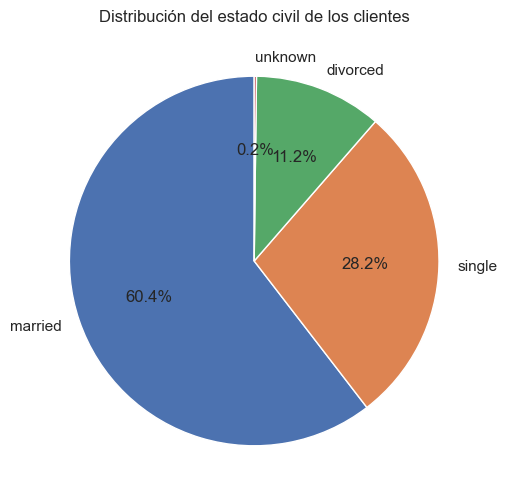

In [32]:

plt.figure(figsize=(6,6))

data["marital"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribución del estado civil de los clientes")
plt.ylabel("")
plt.show()

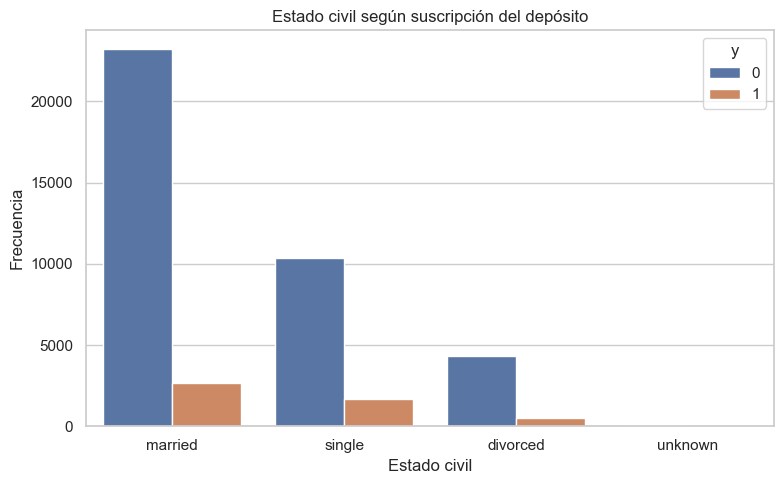

In [33]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x="marital", hue="y")
plt.title("Estado civil según suscripción del depósito")
plt.xlabel("Estado civil")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [34]:
target_rate_table(data, "marital")

y,0,1,conversion_rate
marital,,,
unknown,0.8471,0.1529,0.1529
single,0.8606,0.1394,0.1394
married,0.8981,0.1019,0.1019
divorced,0.8982,0.1018,0.1018


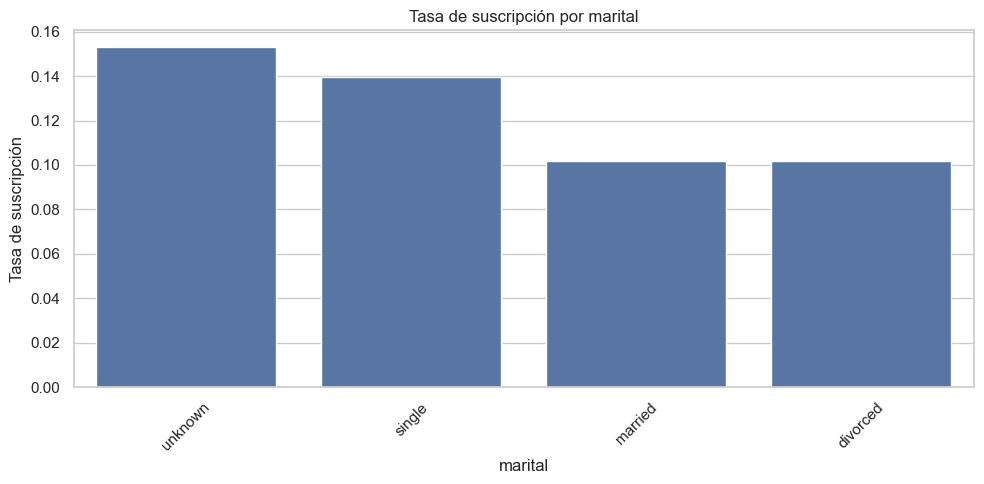

,marital,y
0,unknown,0.152941
1,single,0.139417
2,married,0.101858
3,divorced,0.101798


In [35]:
plot_target_rate_by_category(data, "marital")

- Educación 

In [36]:
data["education"].value_counts()

education
university.degree      12642
high.school             9872
basic.9y                6281
professional.course     5440
basic.4y                4331
basic.6y                2374
unknown                 1794
illiterate                18
Name: count, dtype: int64

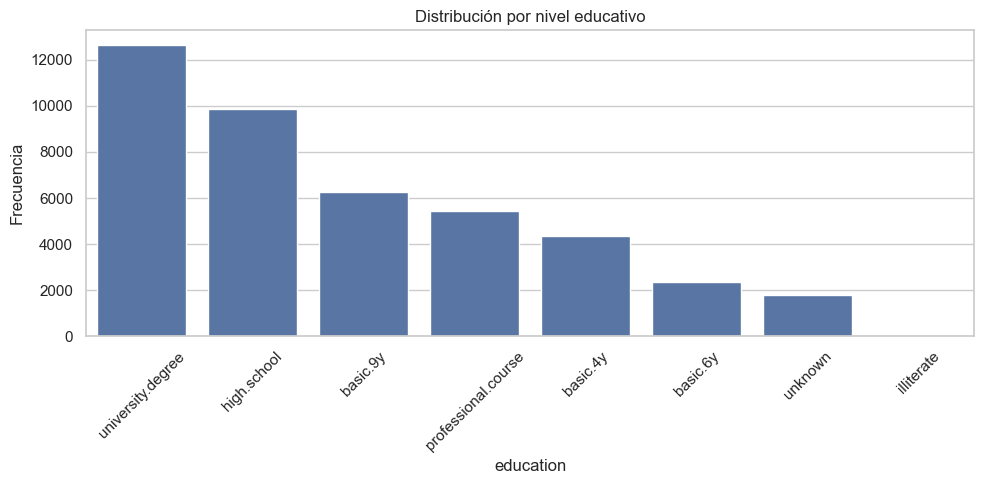

In [37]:
education_order = data["education"].value_counts().index
plot_count(data["education"], "Distribución por nivel educativo", rotation=45, order=education_order)

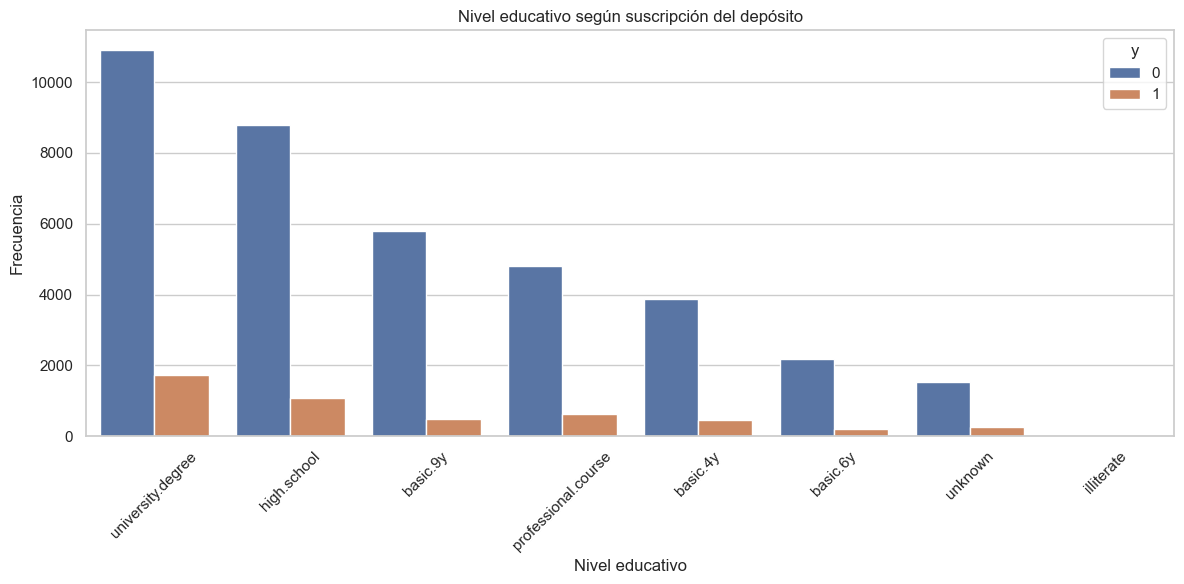

In [38]:
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x="education", hue="y", order=education_order)
plt.title("Nivel educativo según suscripción del depósito")
plt.xlabel("Nivel educativo")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
target_rate_table(data, "education")

y,0,1,conversion_rate
education,,,
illiterate,0.7778,0.2222,0.2222
unknown,0.8556,0.1444,0.1444
university.degree,0.8632,0.1368,0.1368
professional.course,0.8862,0.1138,0.1138
high.school,0.8916,0.1084,0.1084
basic.4y,0.8966,0.1034,0.1034
basic.6y,0.9183,0.0817,0.0817
basic.9y,0.9223,0.0777,0.0777


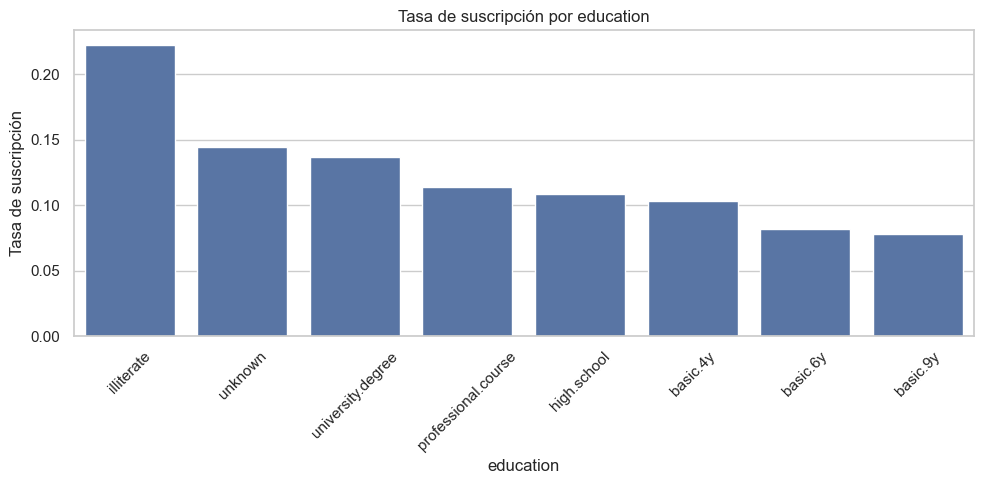

,education,y
0,illiterate,0.222222
1,unknown,0.144370
2,university.degree,0.136766
3,professional.course,0.113787
4,high.school,0.108387
5,basic.4y,0.103440
6,basic.6y,0.081719
7,basic.9y,0.077695


In [40]:
plot_target_rate_by_category(data, "education")

- Ingresos 

In [41]:
data["Income"].describe().round(2)

count     42752.00
mean      93225.59
std       50495.80
min        5841.00
25%       49587.50
50%       93016.00
75%      136732.00
max      180802.00
Name: Income, dtype: float64

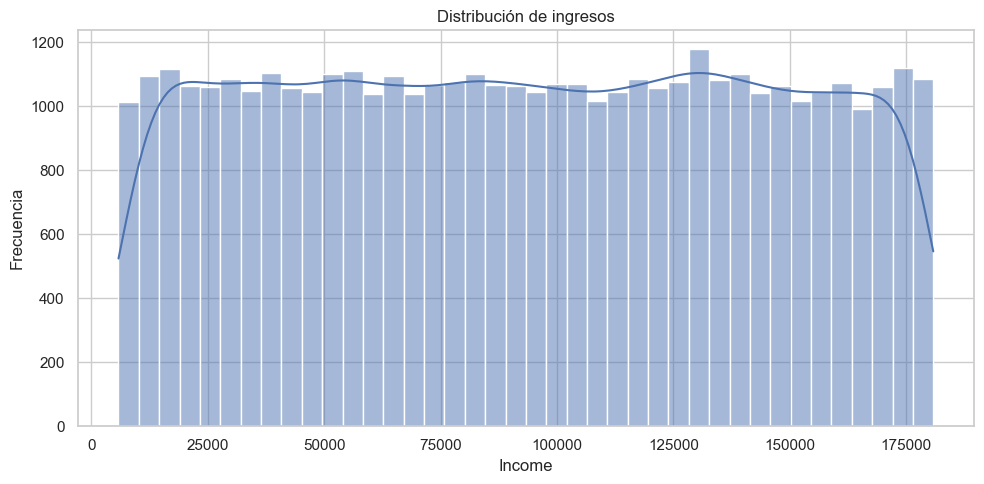

In [42]:
plot_hist(data["Income"], "Distribución de ingresos", bins=40)

In [43]:
target_summary_numeric(data, "Income")

,mean,median,std,min,max
y,,,,,
0,93297.23,93152.0,50524.56,5848,180802
1,92660.66,92380.0,50270.01,5841,180791


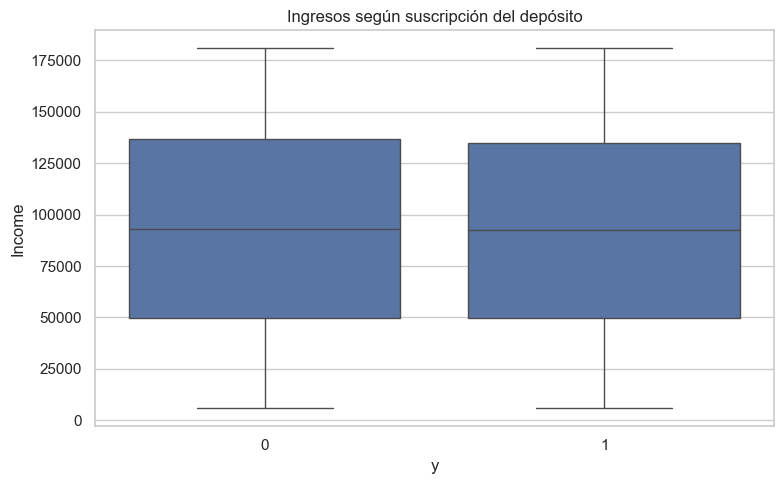

In [44]:
plot_box_by_target(data, "y", "Income", "Ingresos según suscripción del depósito")

- Entorno familiar

In [45]:
data["Family_size"].describe().round(2)

count    42752.00
mean         2.00
std          1.15
min          0.00
25%          1.00
50%          2.00
75%          3.00
max          4.00
Name: Family_size, dtype: float64

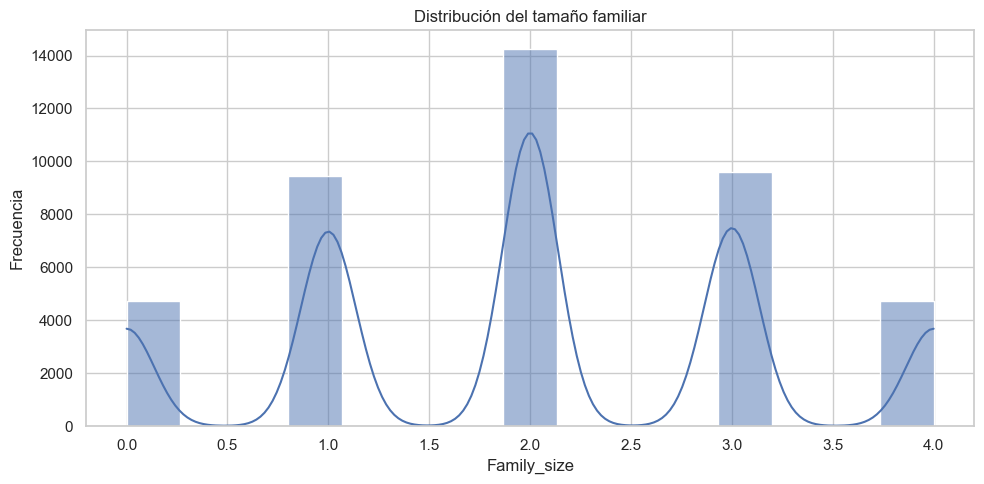

In [46]:
plot_hist(data["Family_size"], "Distribución del tamaño familiar", bins=15)

In [47]:
target_summary_numeric(data, "Family_size")

,mean,median,std,min,max
y,,,,,
0,2.0,2.0,1.15,0,4
1,2.0,2.0,1.16,0,4


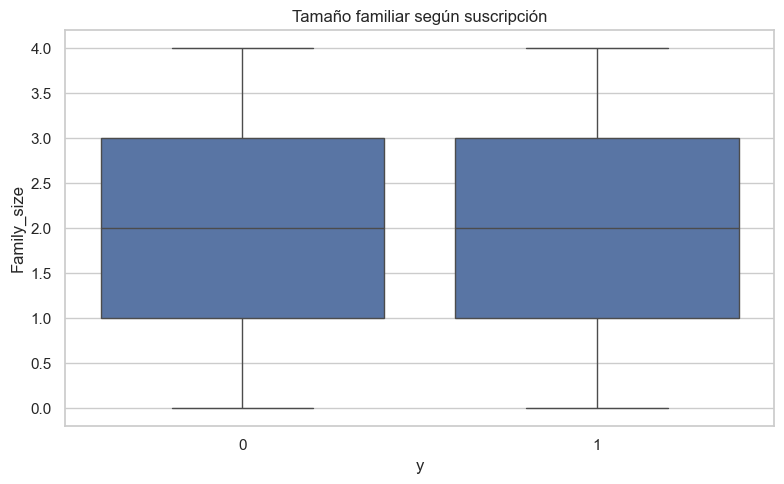

In [48]:
plot_box_by_target(data, "y", "Family_size", "Tamaño familiar según suscripción")


--- Has_kid ---


y,0,1,conversion_rate
Has_kid,,,
0,0.8866,0.1134,0.1134
1,0.8879,0.1121,0.1121


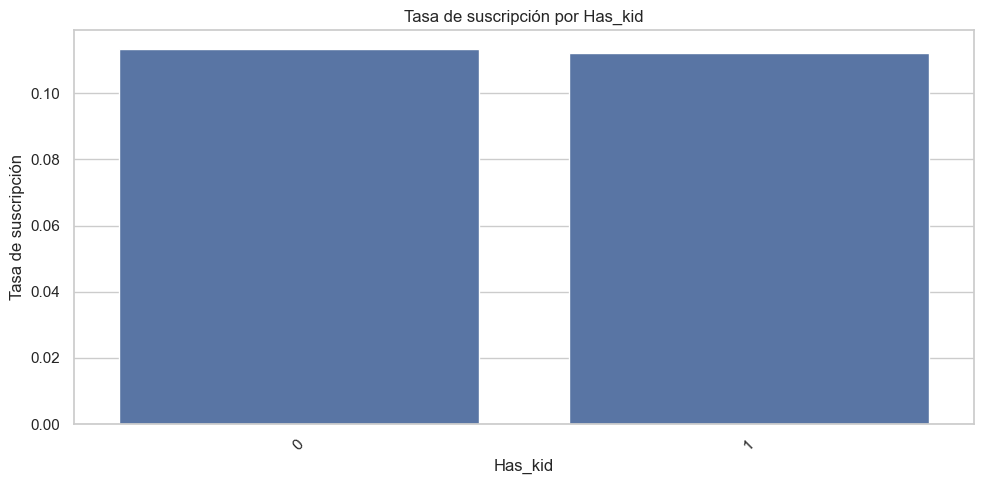

,Has_kid,y
0,0,0.113377
1,1,0.112116



--- Has_teens ---


y,0,1,conversion_rate
Has_teens,,,
0,0.8866,0.1134,0.1134
1,0.8879,0.1121,0.1121


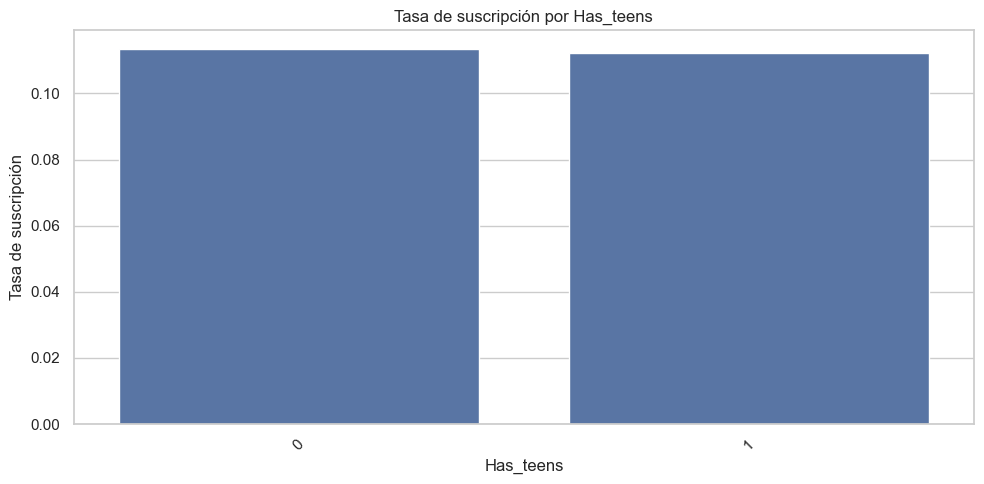

,Has_teens,y
0,0,0.113396
1,1,0.112101


In [49]:
for col in ["Has_kid", "Has_teens"]:
    print(f"\n--- {col} ---")
    display(target_rate_table(data, col))
    plot_target_rate_by_category(data, col)


Resumen numérico de Kidhome


,mean,median,std,min,max
y,,,,,
0,1.01,1.0,0.82,0,2
1,1.01,1.0,0.82,0,2


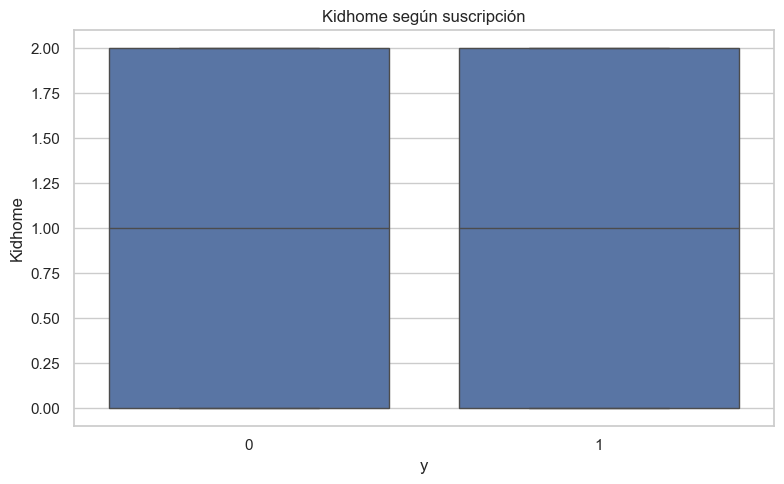


Resumen numérico de Teenhome


,mean,median,std,min,max
y,,,,,
0,1.0,1.0,0.82,0,2
1,1.0,1.0,0.82,0,2


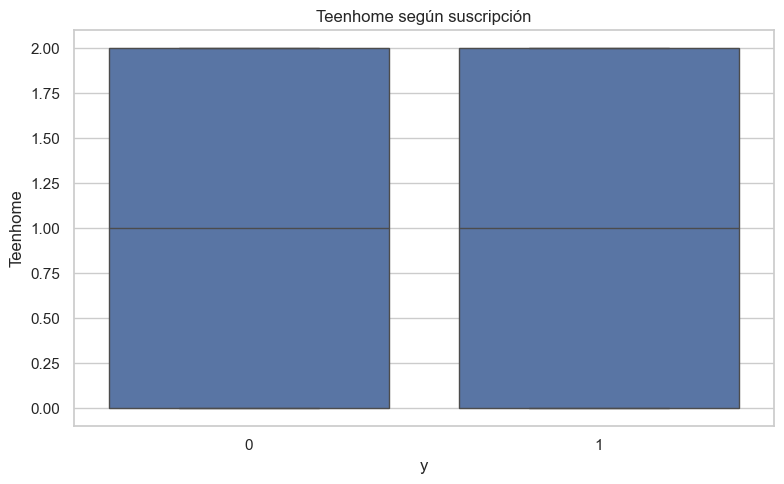

In [50]:
for col in ["Kidhome", "Teenhome"]:
    print(f"\nResumen numérico de {col}")
    display(target_summary_numeric(data, col))
    plot_box_by_target(data, "y", col, f"{col} según suscripción")

---

9. Comportamiento del cliente y dinámica de la campaña 

- Duración de la llamada 

In [51]:
data["duration"].describe().round(2)

count    42752.00
mean       257.77
std        258.78
min          0.00
25%        102.00
50%        179.00
75%        319.00
max       4918.00
Name: duration, dtype: float64

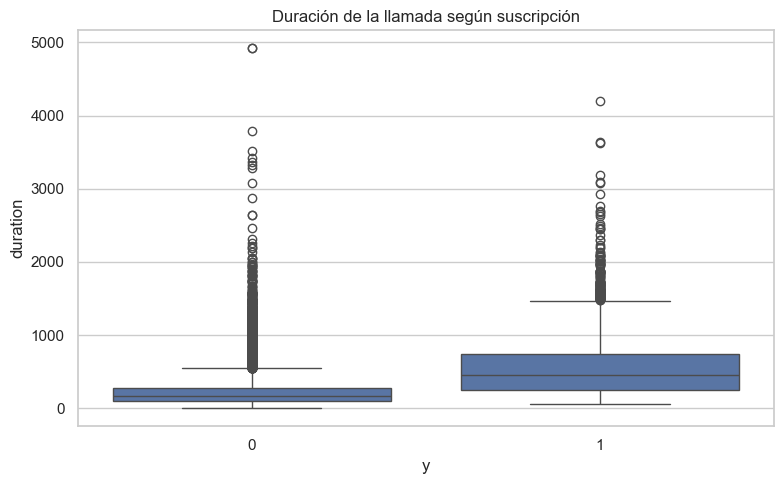

In [52]:
plot_box_by_target(data, "y", "duration", "Duración de la llamada según suscripción")

- Números de leads en campaña

In [53]:
data["campaign"].describe().round(2)

count    42752.00
mean         2.57
std          2.77
min          1.00
25%          1.00
50%          2.00
75%          3.00
max         56.00
Name: campaign, dtype: float64

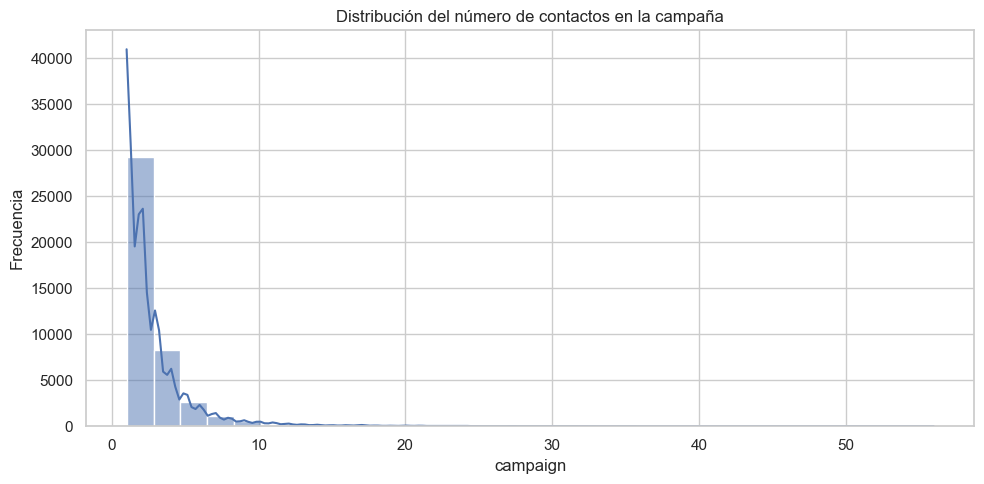

In [54]:
plot_hist(data["campaign"], "Distribución del número de contactos en la campaña", bins=30)

In [55]:
target_summary_numeric(data, "campaign")

,mean,median,std,min,max
y,,,,,
0,2.63,2.0,2.87,1,56
1,2.05,2.0,1.66,1,23


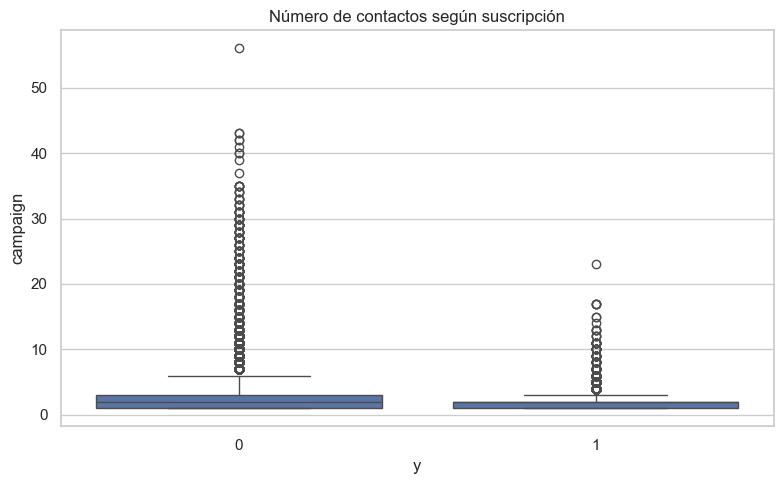

In [56]:
plot_box_by_target(data, "y", "campaign", "Número de contactos según suscripción")

- Leads previos 


Resumen de previous


count    42752.00
mean         0.17
std          0.50
min          0.00
25%          0.00
50%          0.00
75%          0.00
max          7.00
Name: previous, dtype: float64

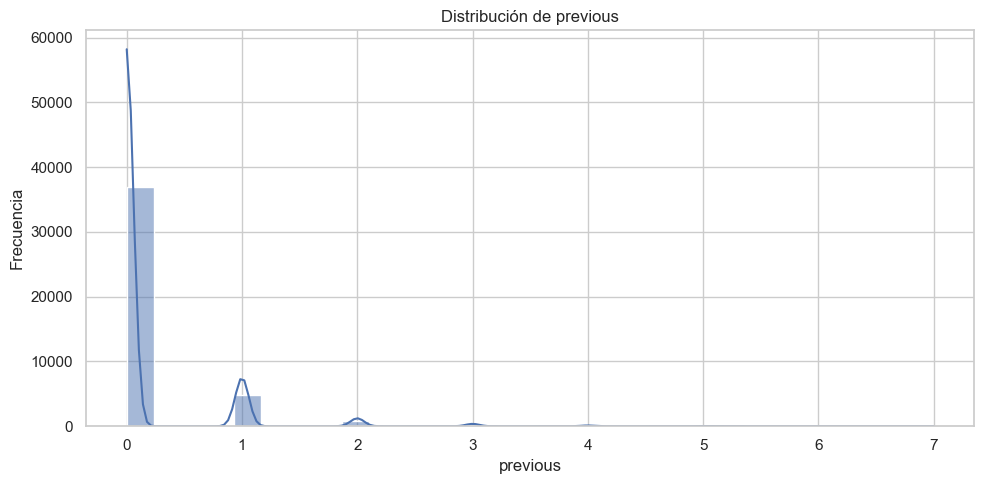

,mean,median,std,min,max
y,,,,,
0,0.13,0.0,0.41,0,7
1,0.50,0.0,0.87,0,6


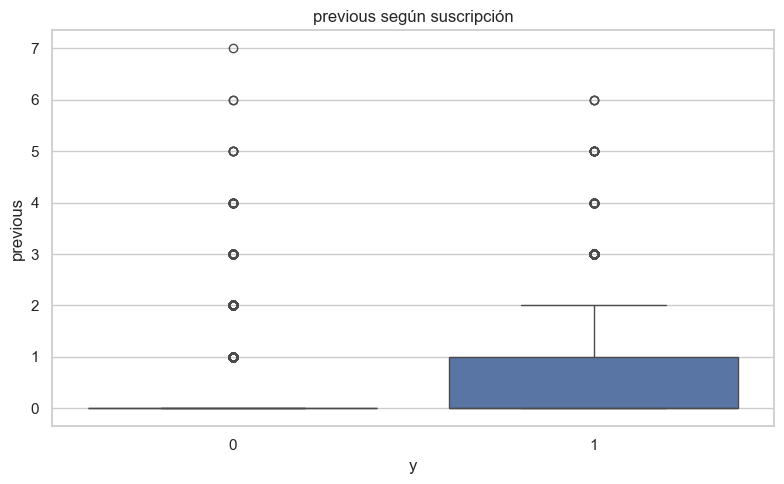


Resumen de pdays


count    1577.00
mean        6.08
std         3.87
min         0.00
25%         3.00
50%         6.00
75%         7.00
max        27.00
Name: pdays, dtype: float64

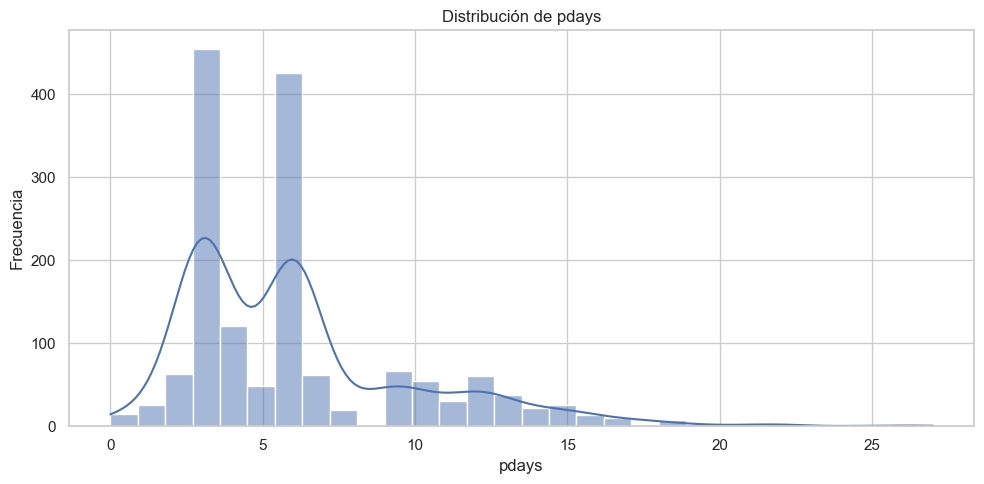

,mean,median,std,min,max
y,,,,,
0,6.25,6.0,4.0,0.0,22.0
1,5.98,6.0,3.8,0.0,27.0


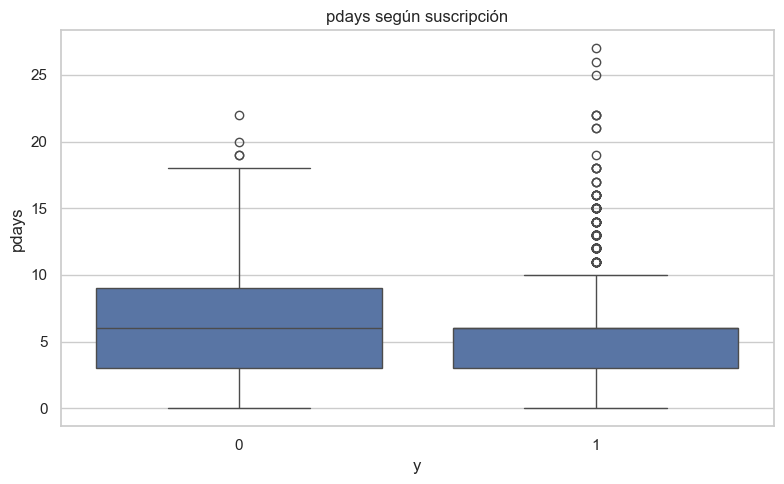

In [57]:
for col in ["previous", "pdays"]:
    print(f"\nResumen de {col}")
    display(data[col].describe().round(2))
    plot_hist(data[col], f"Distribución de {col}", bins=30)
    display(target_summary_numeric(data, col))
    plot_box_by_target(data, "y", col, f"{col} según suscripción")

In [58]:
data["was_contacted_before"].value_counts()

was_contacted_before
0    36883
1     5869
Name: count, dtype: int64

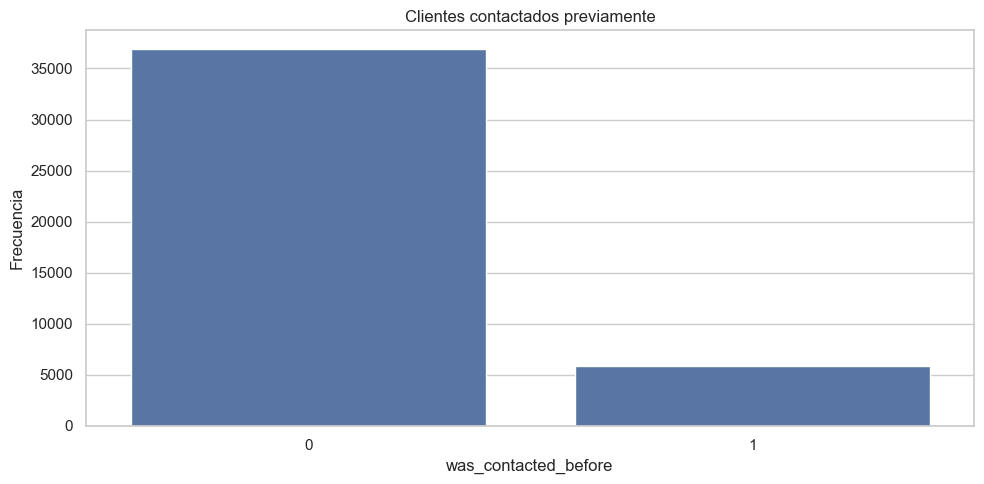

In [59]:
plot_count(data["was_contacted_before"], "Clientes contactados previamente")

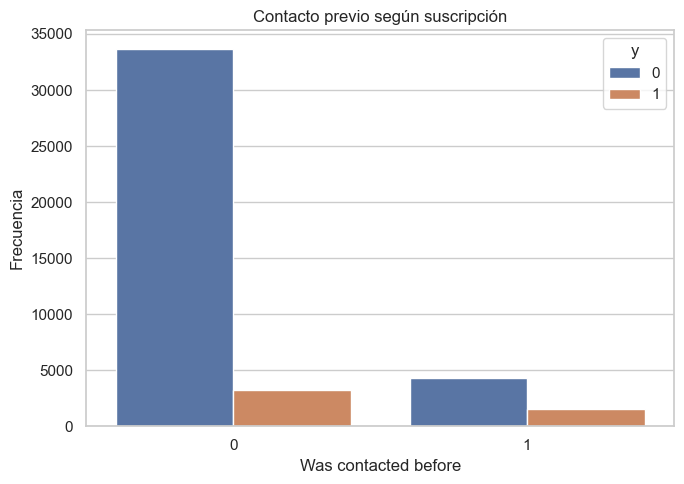

In [60]:
plt.figure(figsize=(7, 5))
sns.countplot(data=data, x="was_contacted_before", hue="y")
plt.title("Contacto previo según suscripción")
plt.xlabel("Was contacted before")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [61]:
target_rate_table(data, "was_contacted_before")

y,0,1,conversion_rate
was_contacted_before,,,
1,0.7335,0.2665,0.2665
0,0.9120,0.0880,0.0880


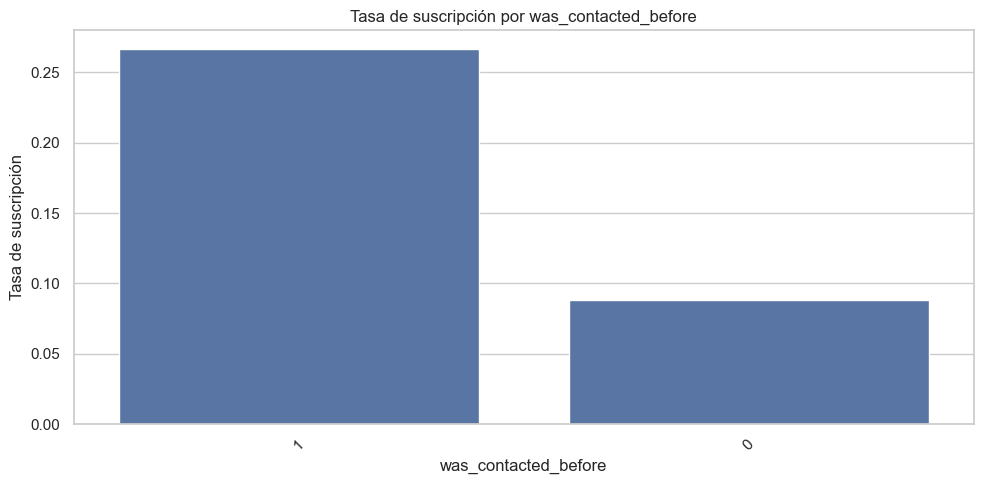

,was_contacted_before,y
0,1,0.266485
1,0,0.088035


In [62]:
plot_target_rate_by_category(data, "was_contacted_before")

- Resultado previo de campaña 

In [63]:
data["poutcome"].value_counts()

poutcome
nonexistent    36883
failure         4443
success         1426
Name: count, dtype: int64

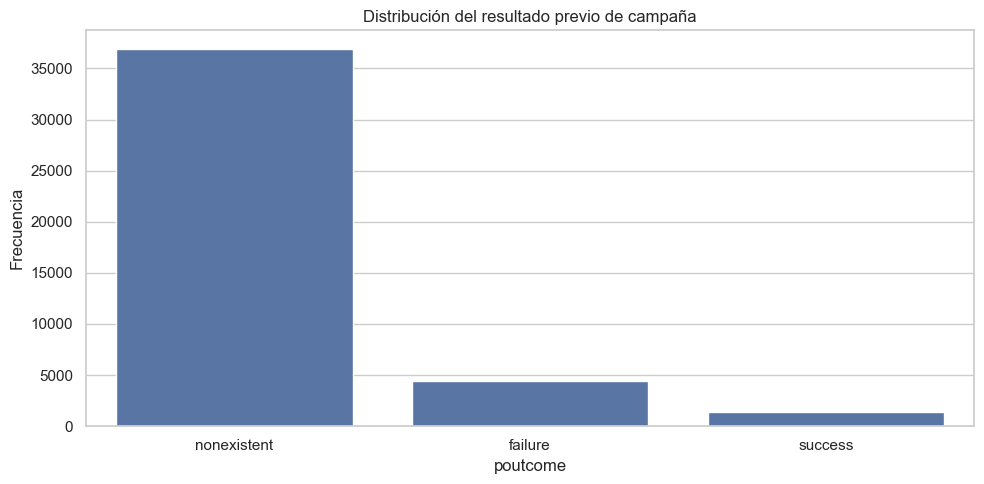

In [64]:
plot_count(data["poutcome"], "Distribución del resultado previo de campaña")

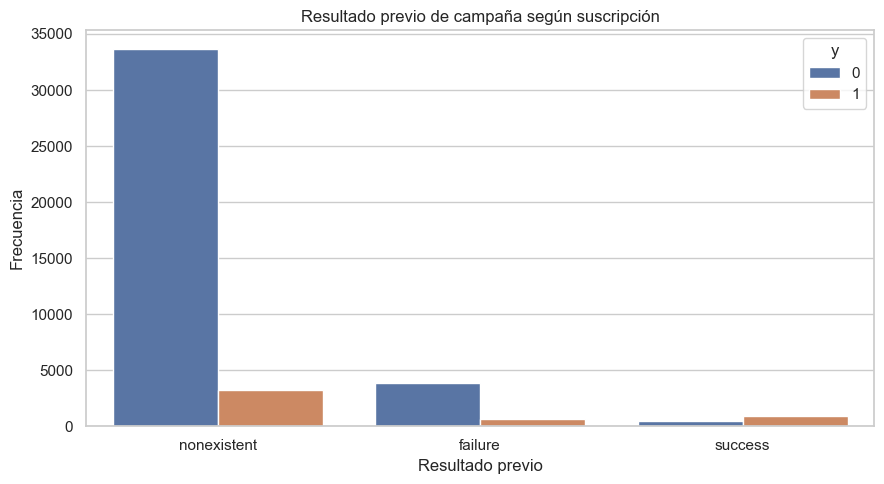

In [65]:
plt.figure(figsize=(9, 5))
sns.countplot(data=data, x="poutcome", hue="y")
plt.title("Resultado previo de campaña según suscripción")
plt.xlabel("Resultado previo")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [66]:
target_rate_table(data, "poutcome")

y,0,1,conversion_rate
poutcome,,,
success,0.3457,0.6543,0.6543
failure,0.8580,0.1420,0.1420
nonexistent,0.9120,0.0880,0.0880


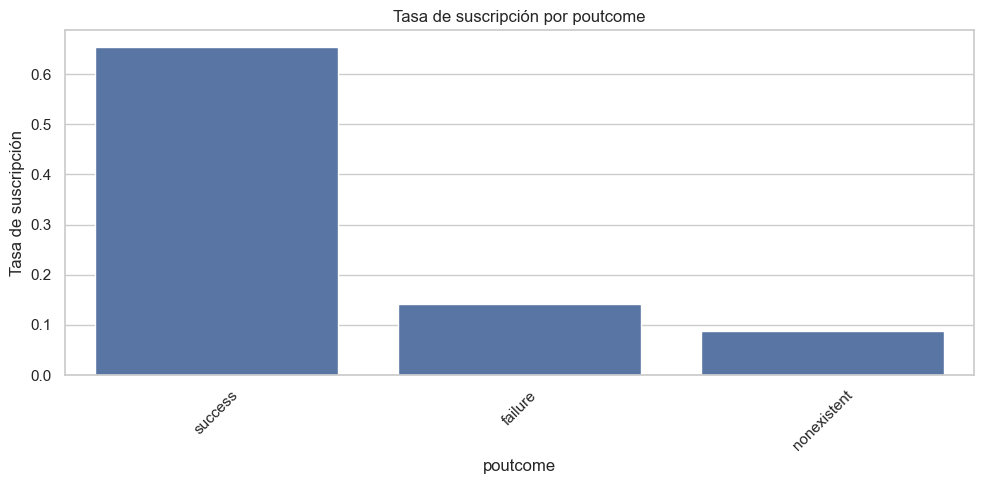

,poutcome,y
0,success,0.654278
1,failure,0.142021
2,nonexistent,0.088035


In [67]:
plot_target_rate_by_category(data, "poutcome")

- Canal de contacto

In [68]:
data["contact"].value_counts()

contact
cellular     27232
telephone    15520
Name: count, dtype: int64

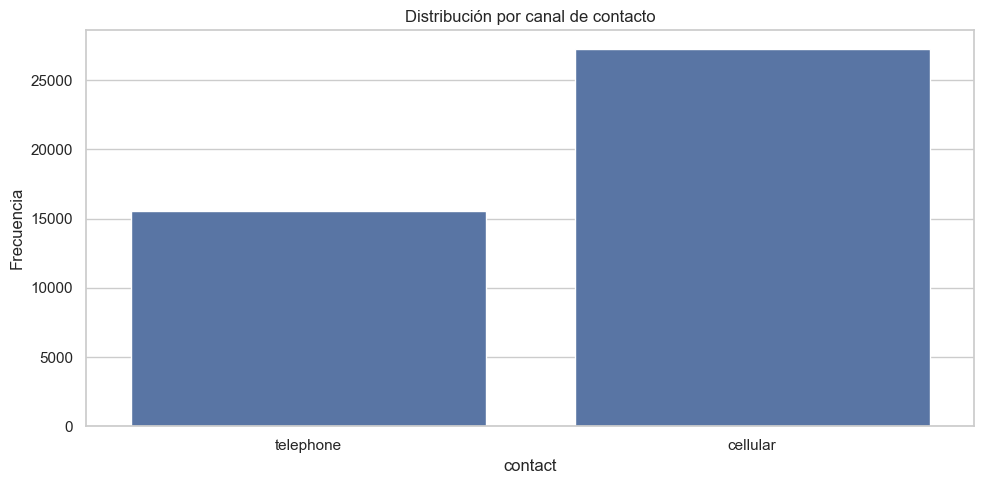

In [69]:
plot_count(data["contact"], "Distribución por canal de contacto")

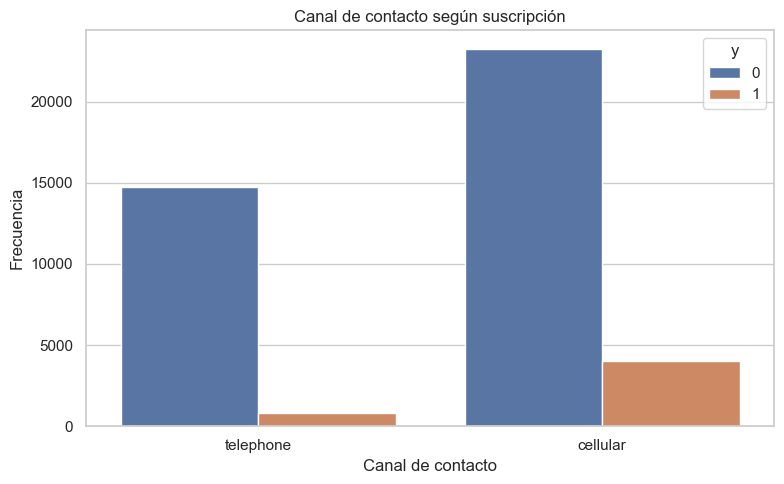

In [70]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x="contact", hue="y")
plt.title("Canal de contacto según suscripción")
plt.xlabel("Canal de contacto")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [71]:
target_rate_table(data, "contact")

y,0,1,conversion_rate
contact,,,
cellular,0.8527,0.1473,0.1473
telephone,0.9485,0.0515,0.0515


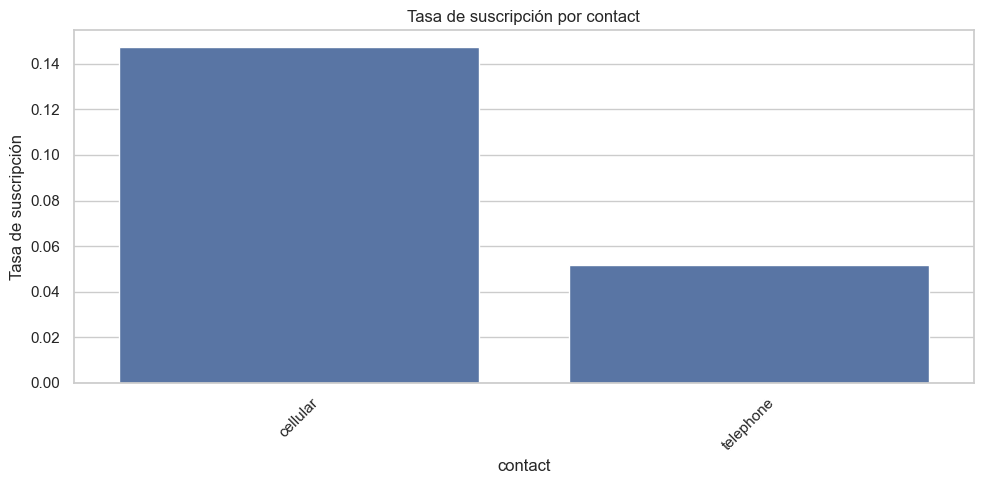

,contact,y
0,cellular,0.147290
1,telephone,0.051546


In [72]:
plot_target_rate_by_category(data, "contact")

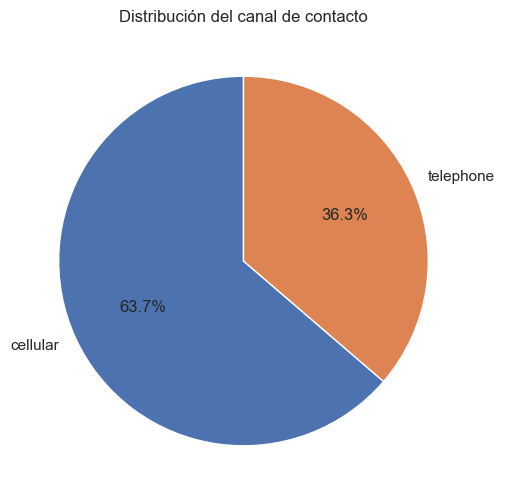

In [73]:
plt.figure(figsize=(6,6))

data["contact"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribución del canal de contacto")
plt.ylabel("")
plt.show()

- Comportamiento digital

In [74]:
data["NumWebVisitsMonth"].describe().round(2)

count    42752.00
mean        16.59
std          9.24
min          1.00
25%          9.00
50%         17.00
75%         25.00
max         32.00
Name: NumWebVisitsMonth, dtype: float64

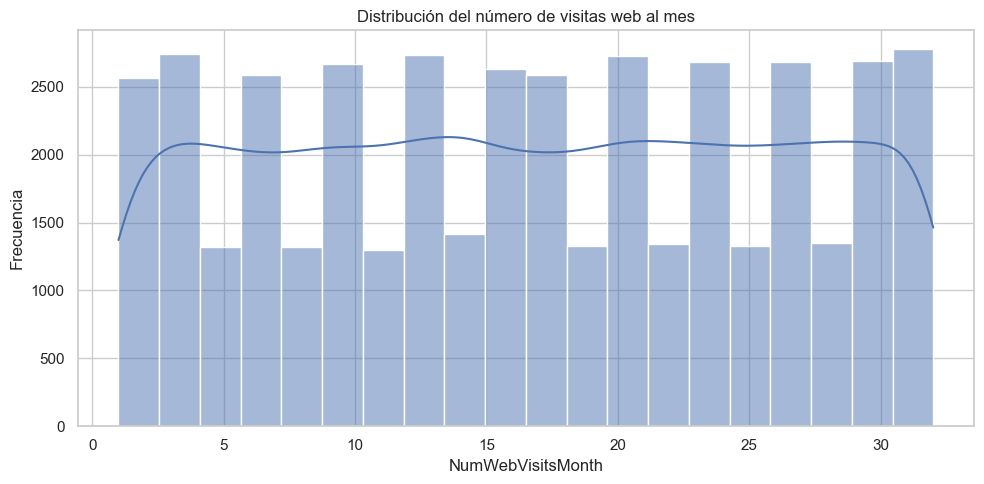

In [75]:
plot_hist(data["NumWebVisitsMonth"], "Distribución del número de visitas web al mes", bins=20)

In [76]:
target_summary_numeric(data, "NumWebVisitsMonth")

,mean,median,std,min,max
y,,,,,
0,16.59,17.0,9.24,1,32
1,16.59,17.0,9.24,1,32


In [77]:
target_summary_numeric(data, "NumWebVisitsMonth")

,mean,median,std,min,max
y,,,,,
0,16.59,17.0,9.24,1,32
1,16.59,17.0,9.24,1,32


- Antigüedad del cliente


Resumen de Customer_tenure_years


count    42752.00
mean        12.84
std          0.99
min         11.00
25%         12.00
50%         13.00
75%         14.00
max         14.00
Name: Customer_tenure_years, dtype: float64

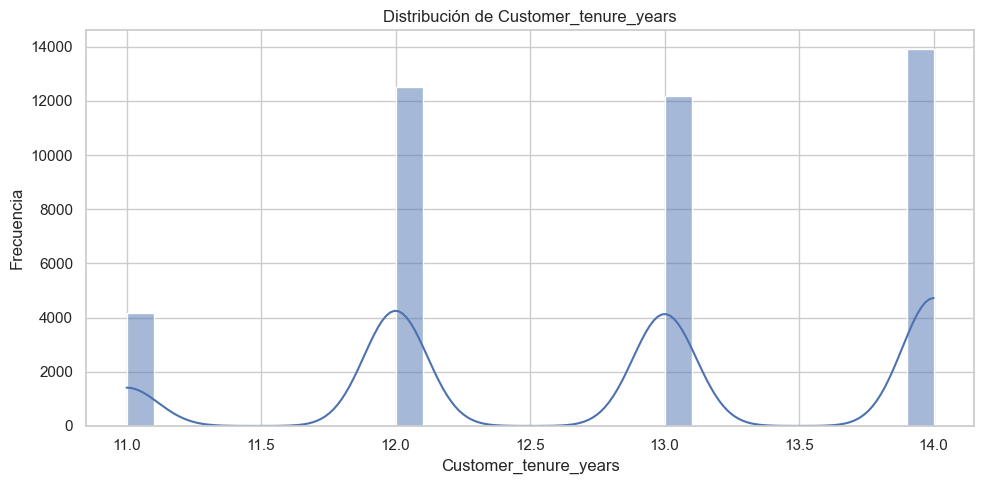

,mean,median,std,min,max
y,,,,,
0,12.91,13.0,0.97,11.0,14.0
1,12.23,12.0,0.91,11.0,14.0


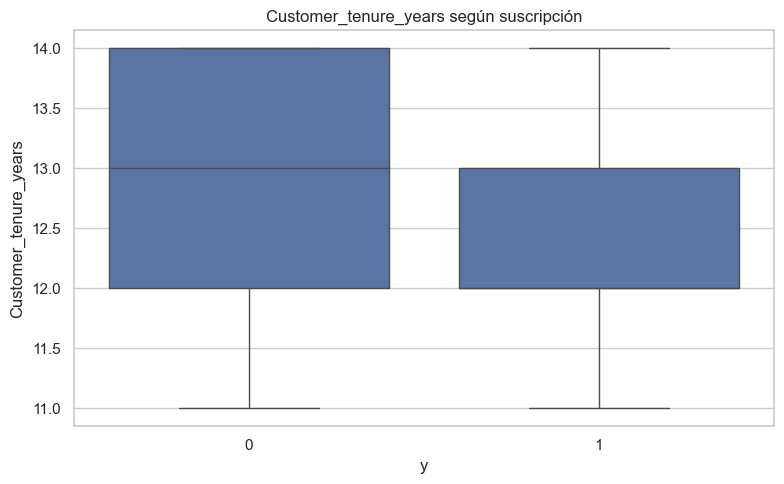


Resumen de tenure_at_contact_days


count    42752.00
mean         4.14
std          1.75
min          0.00
25%          3.00
50%          4.00
75%          5.00
max          8.00
Name: tenure_at_contact_days, dtype: float64

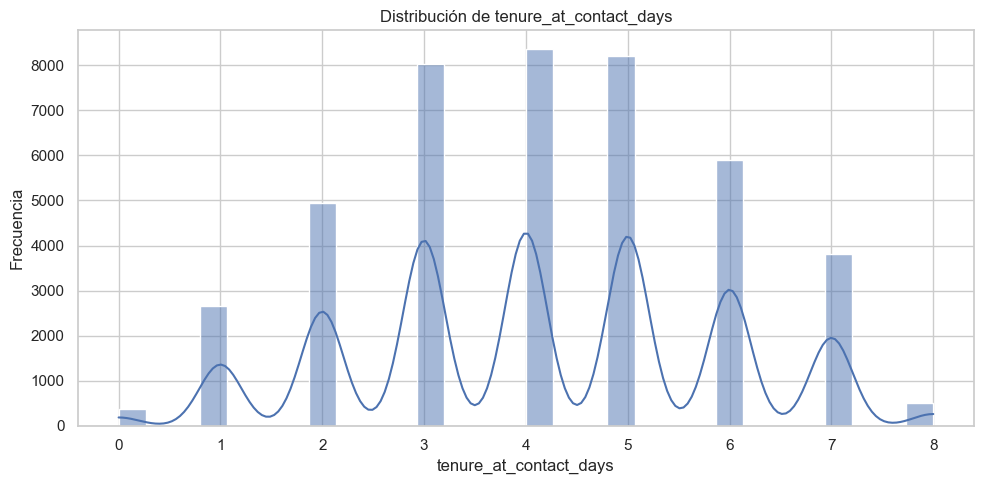

,mean,median,std,min,max
y,,,,,
0,4.22,4.0,1.74,0.0,8.0
1,3.55,4.0,1.71,0.0,8.0


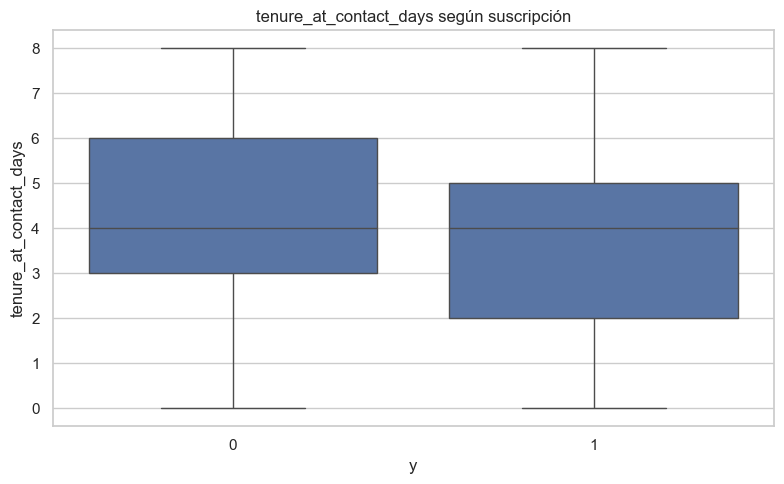

In [78]:
for col in ["Customer_tenure_years", "tenure_at_contact_days"]:
    print(f"\nResumen de {col}")
    display(data[col].describe().round(2))
    plot_hist(data[col], f"Distribución de {col}", bins=30)
    display(target_summary_numeric(data, col))
    plot_box_by_target(data, "y", col, f"{col} según suscripción")

---

10. Contexto económico 

In [79]:
economic_vars = [
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed"
]

In [80]:
data[economic_vars].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
emp.var.rate,42752.0,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40
cons.price.idx,42752.0,93.58,0.58,92.20,93.08,93.75,93.99,94.77
cons.conf.idx,42752.0,-40.51,4.64,-50.80,-42.70,-41.80,-36.40,-26.90
euribor3m,42752.0,3.88,1.62,0.63,1.48,4.86,4.96,5.04
nr.employed,42752.0,5166.87,72.39,4963.60,5099.10,5191.00,5228.10,5228.10


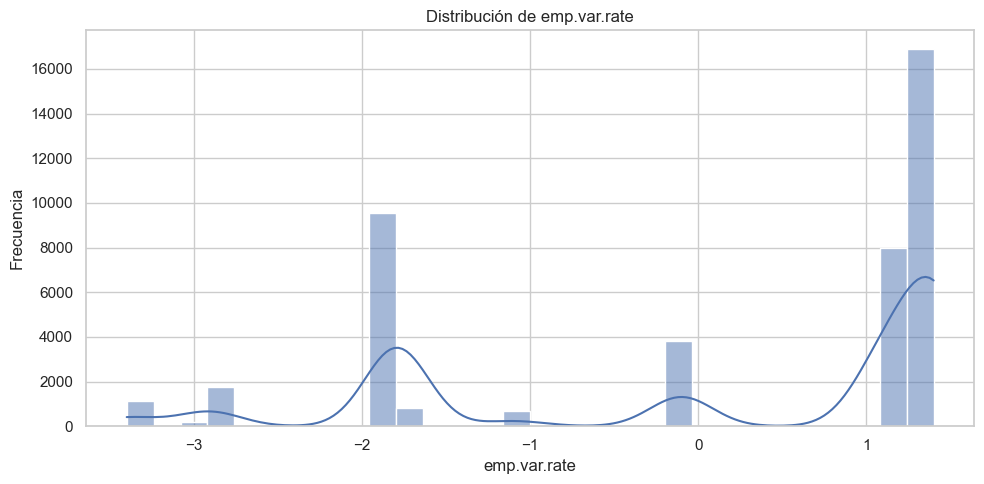

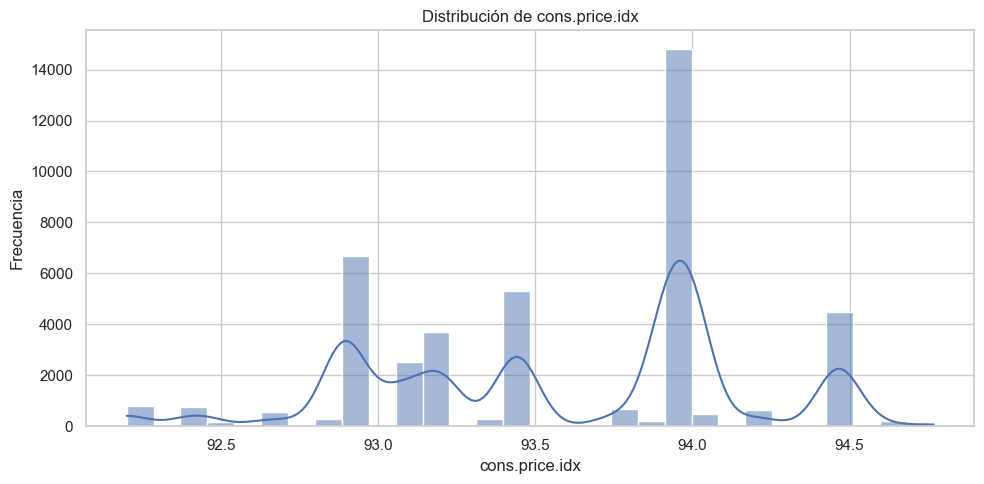

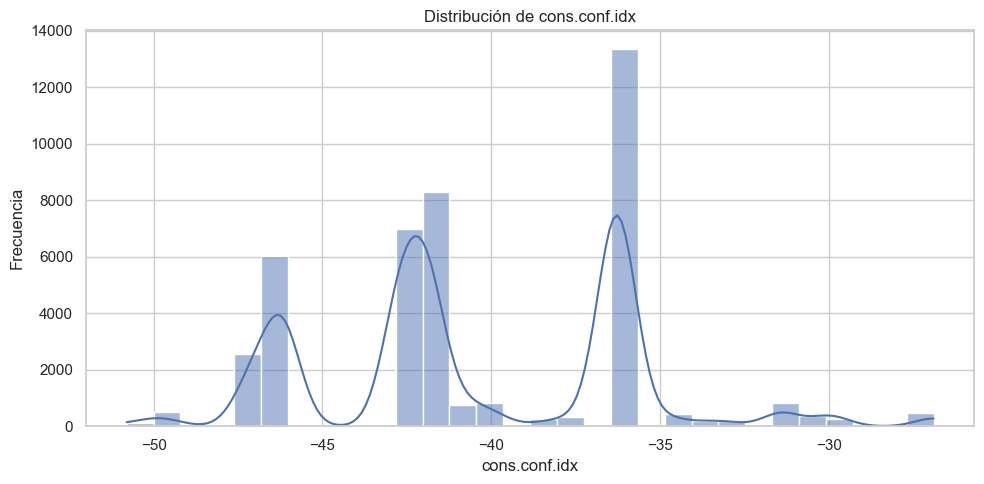

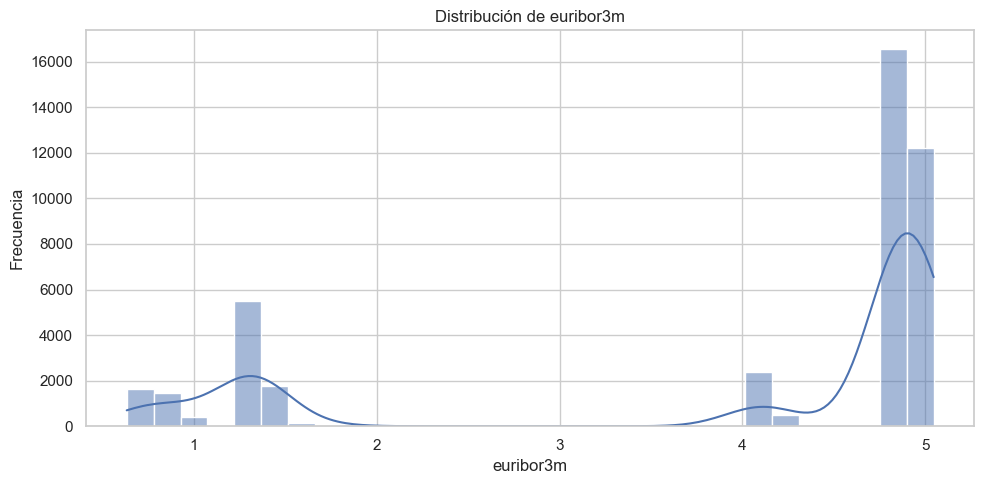

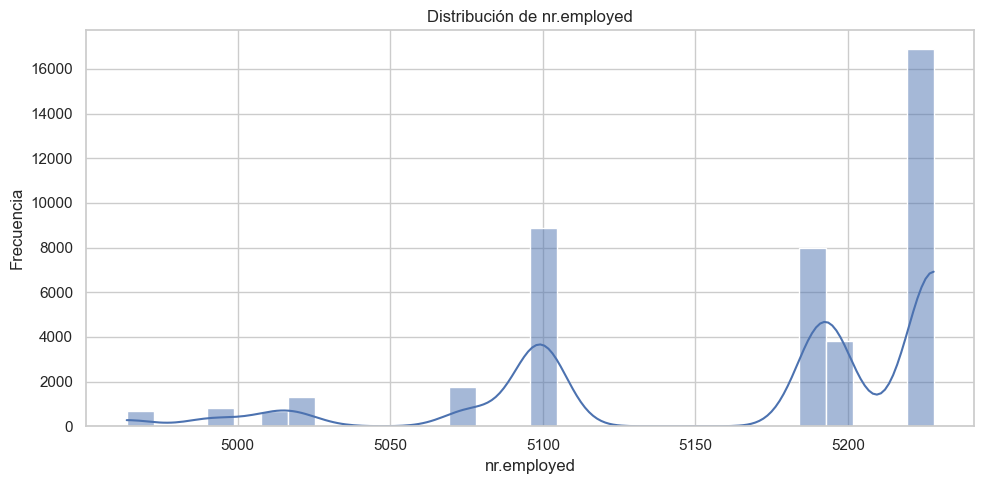

In [81]:
for col in economic_vars:
    plot_hist(data[col], f"Distribución de {col}", bins=30)


Resumen de emp.var.rate según y


,mean,median,std,min,max
y,,,,,
0,0.24,1.1,1.49,-3.4,1.4
1,-1.24,-1.8,1.63,-3.4,1.4


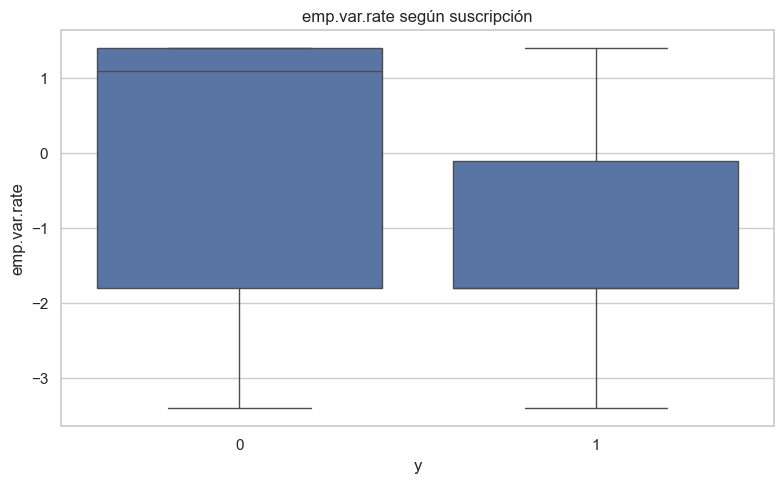


Resumen de cons.price.idx según y


,mean,median,std,min,max
y,,,,,
0,93.60,93.92,0.56,92.2,94.77
1,93.36,93.20,0.68,92.2,94.77


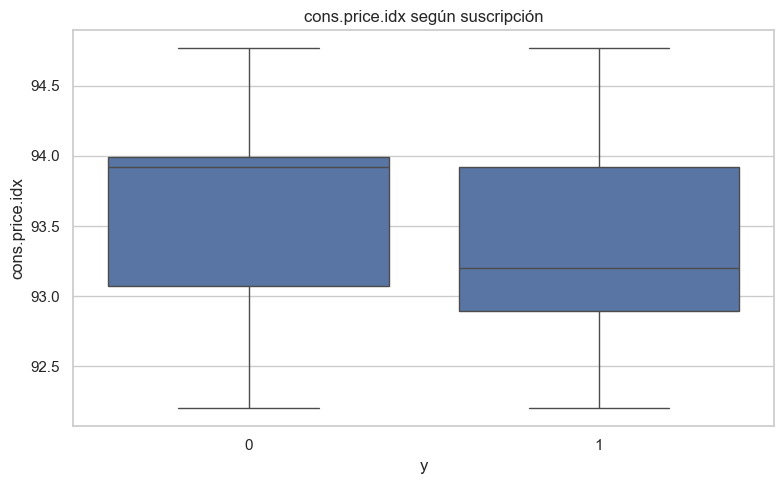


Resumen de cons.conf.idx según y


,mean,median,std,min,max
y,,,,,
0,-40.60,-41.8,4.40,-50.8,-26.9
1,-39.77,-40.3,6.16,-50.8,-26.9


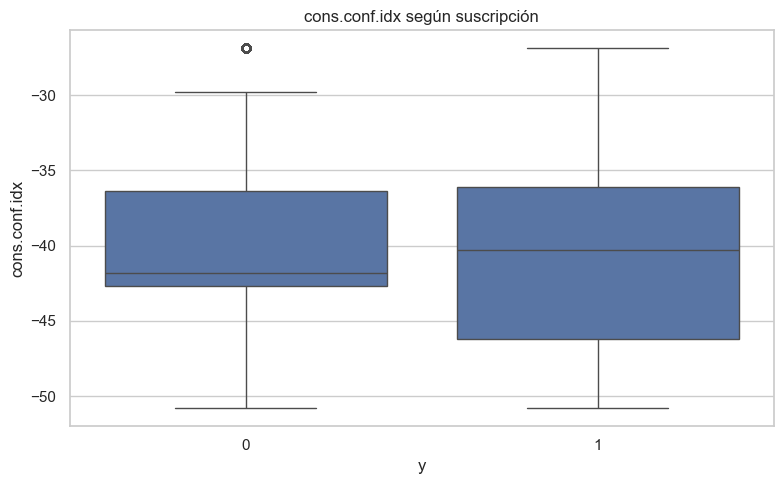


Resumen de euribor3m según y


,mean,median,std,min,max
y,,,,,
0,4.04,4.86,1.51,0.63,5.04
1,2.68,1.40,1.91,0.63,4.97


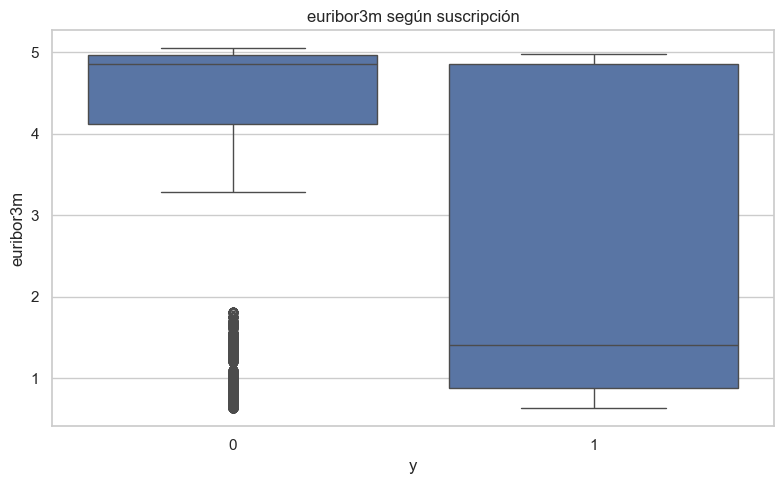


Resumen de nr.employed según y


,mean,median,std,min,max
y,,,,,
0,5176.04,5195.8,64.69,4963.6,5228.1
1,5094.55,5099.1,87.62,4963.6,5228.1


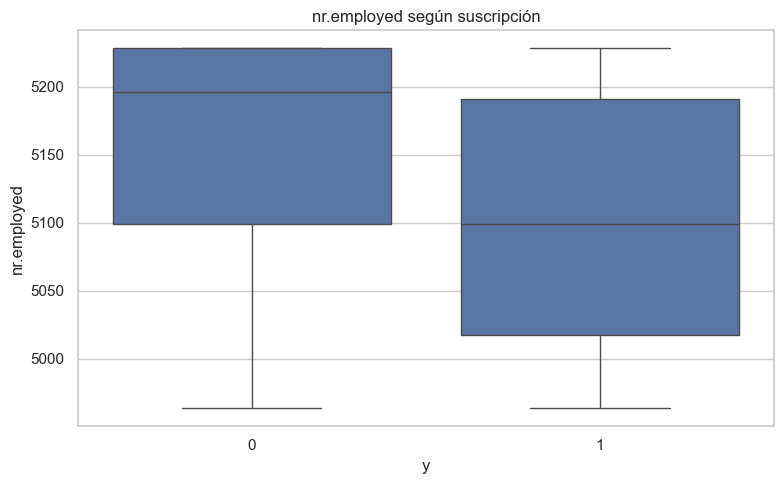

In [82]:
for col in economic_vars:
    print(f"\nResumen de {col} según y")
    display(target_summary_numeric(data, col))
    plot_box_by_target(data, "y", col, f"{col} según suscripción")

---

11. Análisis temporal

In [83]:
month_map = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

data["contact_month_name"] = data["contact_month"].map(month_map)

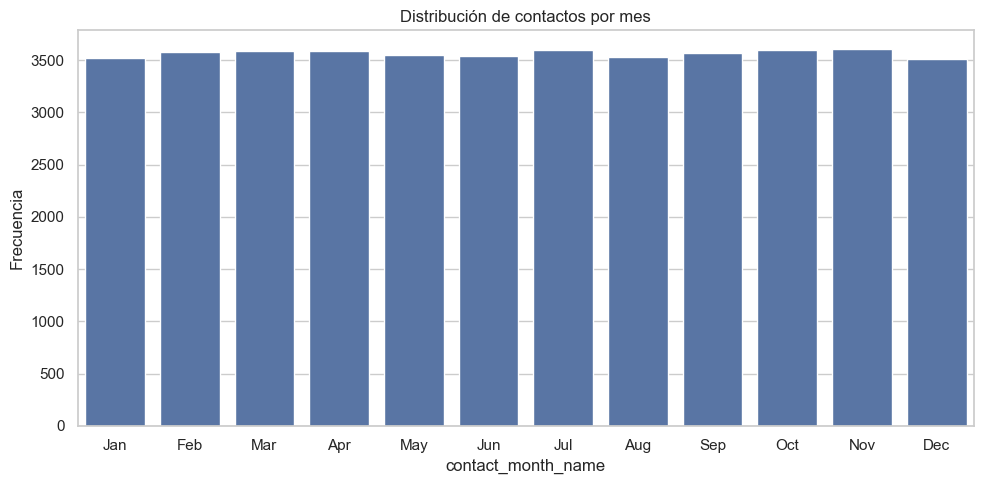

In [84]:
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plot_count(
    data["contact_month_name"],
    "Distribución de contactos por mes",
    order=[m for m in month_order if m in data["contact_month_name"].dropna().unique()]
)

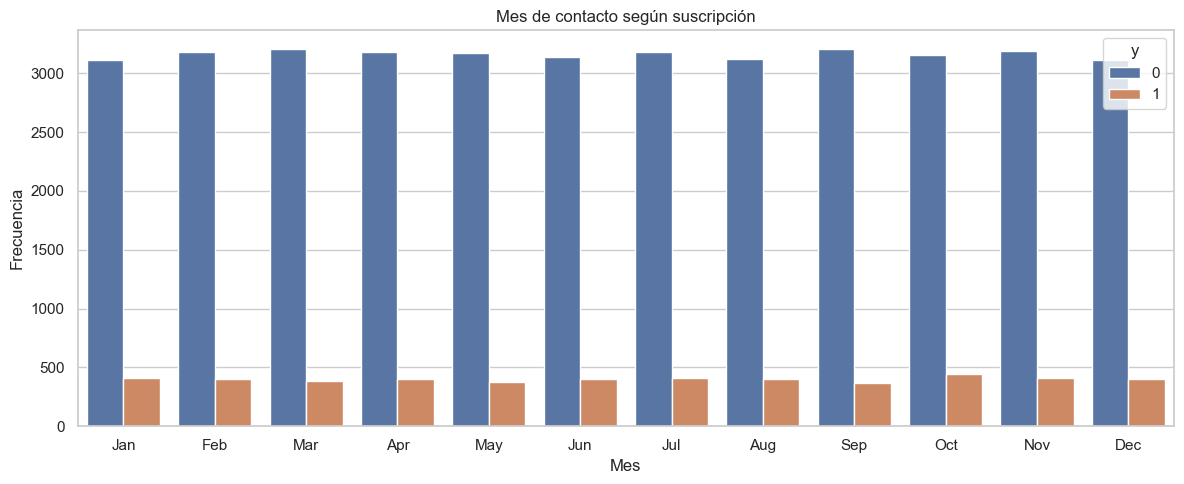

In [85]:
plt.figure(figsize=(12, 5))
sns.countplot(data=data, x="contact_month_name", hue="y",
              order=[m for m in month_order if m in data["contact_month_name"].dropna().unique()])
plt.title("Mes de contacto según suscripción")
plt.xlabel("Mes")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [86]:
target_rate_table(data, "contact_month_name")

y,0,1,conversion_rate
contact_month_name,,,
Oct,0.8764,0.1236,0.1236
Jan,0.8840,0.1160,0.1160
Nov,0.8851,0.1149,0.1149
Aug,0.8854,0.1146,0.1146
Dec,0.8855,0.1145,0.1145
Jul,0.8859,0.1141,0.1141
Jun,0.8867,0.1133,0.1133
Apr,0.8881,0.1119,0.1119
Feb,0.8887,0.1113,0.1113


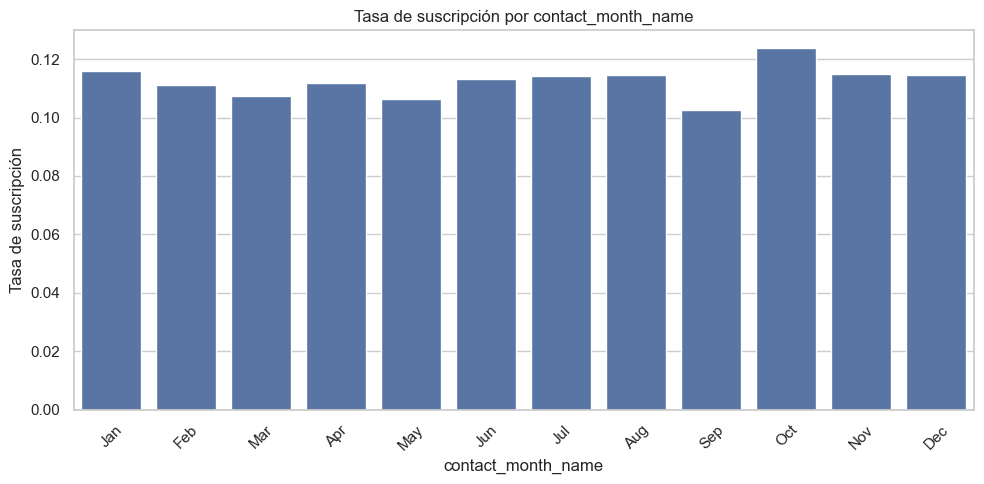

,contact_month_name,y
0,Oct,0.123645
1,Jan,0.116008
2,Nov,0.114904
3,Aug,0.114577
4,Dec,0.114465
5,Jul,0.114111
6,Jun,0.113341
7,Apr,0.111949
8,Feb,0.111266
9,Mar,0.107272


In [87]:
plot_target_rate_by_category(
    data,
    "contact_month_name",
    order=[m for m in month_order if m in data["contact_month_name"].dropna().unique()]
)

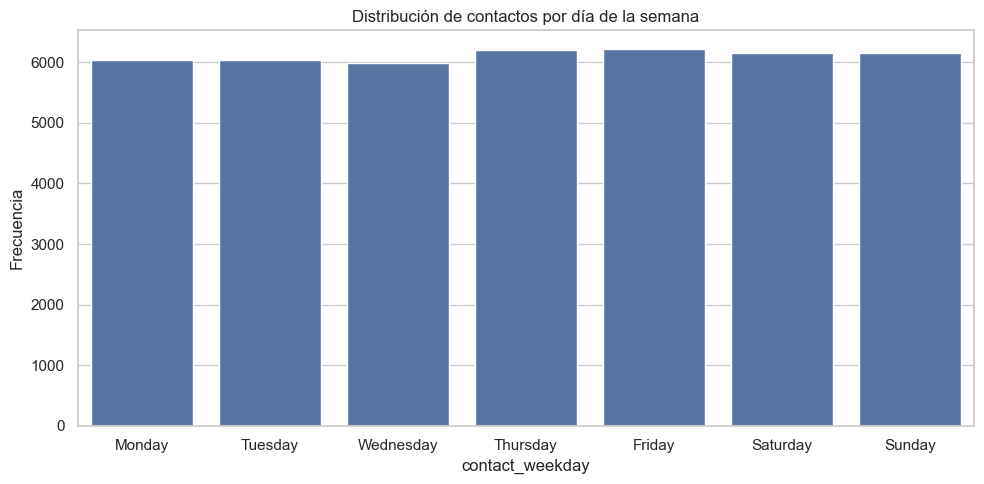

In [88]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plot_count(
    data["contact_weekday"],
    "Distribución de contactos por día de la semana",
    order=[d for d in weekday_order if d in data["contact_weekday"].dropna().unique()]
)

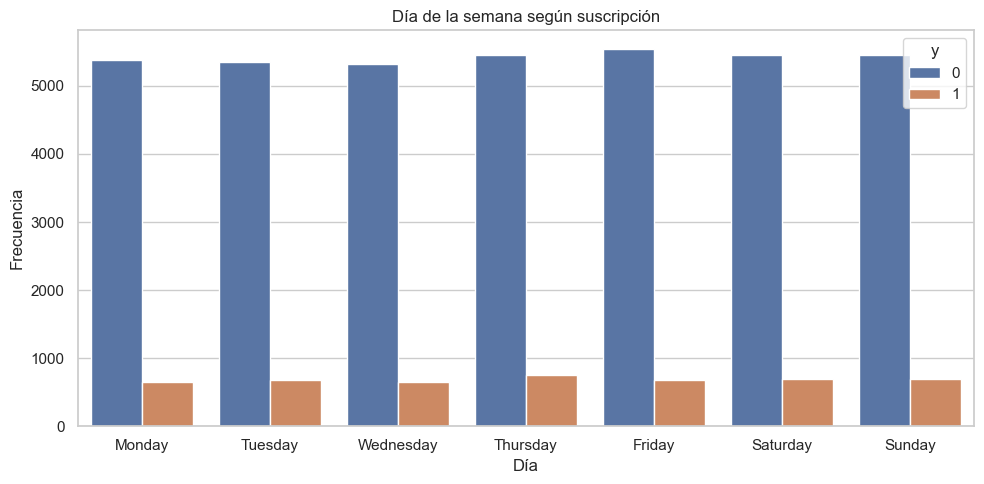

In [89]:
plt.figure(figsize=(10, 5))
sns.countplot(data=data, x="contact_weekday", hue="y",
              order=[d for d in weekday_order if d in data["contact_weekday"].dropna().unique()])
plt.title("Día de la semana según suscripción")
plt.xlabel("Día")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [90]:
target_rate_table(data, "contact_weekday")

y,0,1,conversion_rate
contact_weekday,,,
Thursday,0.8793,0.1207,0.1207
Tuesday,0.8863,0.1137,0.1137
Saturday,0.8863,0.1137,0.1137
Sunday,0.8875,0.1125,0.1125
Wednesday,0.8903,0.1097,0.1097
Monday,0.8911,0.1089,0.1089
Friday,0.8917,0.1083,0.1083


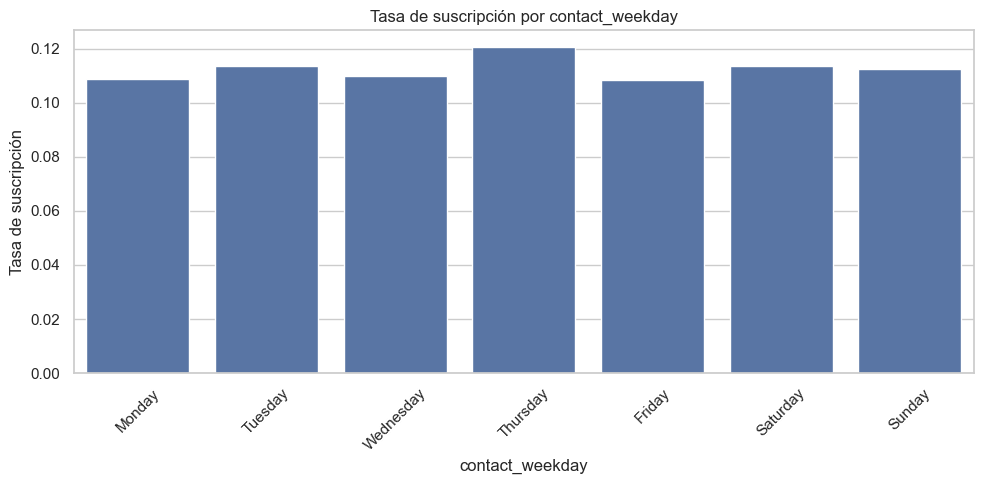

,contact_weekday,y
0,Thursday,0.120684
1,Tuesday,0.113727
2,Saturday,0.113714
3,Sunday,0.112539
4,Wednesday,0.109717
5,Monday,0.108865
6,Friday,0.108339


In [91]:
plot_target_rate_by_category(
    data,
    "contact_weekday",
    order=[d for d in weekday_order if d in data["contact_weekday"].dropna().unique()]
)

---

12. Relación global con la variable objetivo 

In [92]:
key_numeric_vars = [
    "age",
    "Income",
    "duration",
    "campaign",
    "previous",
    "pdays",
    "NumWebVisitsMonth",
    "Customer_tenure_years",
    "tenure_at_contact_days",
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed"
]

summary_by_target = data.groupby("y")[key_numeric_vars].mean().T.round(2)
summary_by_target["difference_1_minus_0"] = (summary_by_target[1] - summary_by_target[0]).round(2)

summary_by_target.sort_values("difference_1_minus_0", ascending=False)

y,0,1,difference_1_minus_0
duration,220.39,552.56,332.17
age,39.64,40.56,0.92
cons.conf.idx,-40.60,-39.77,0.83
previous,0.13,0.50,0.37
NumWebVisitsMonth,16.59,16.59,0.00
cons.price.idx,93.60,93.36,-0.24
pdays,6.25,5.98,-0.27
campaign,2.63,2.05,-0.58
tenure_at_contact_days,4.22,3.55,-0.67
Customer_tenure_years,12.91,12.23,-0.68


In [93]:
key_categorical_vars = [
    "job",
    "marital",
    "education",
    "contact",
    "poutcome",
    "was_contacted_before",
    "contact_month_name",
    "contact_weekday"
]

for col in key_categorical_vars:
    print(f"\n===== {col} =====")
    display(target_rate_table(data, col))


===== job =====


y,0,1,conversion_rate
job,,,
student,0.6864,0.3136,0.3136
retired,0.7475,0.2525,0.2525
unemployed,0.8555,0.1445,0.1445
admin.,0.8702,0.1298,0.1298
unknown,0.8866,0.1134,0.1134
management,0.8887,0.1113,0.1113
self-employed,0.8914,0.1086,0.1086
technician,0.8916,0.1084,0.1084
housemaid,0.9006,0.0994,0.0994



===== marital =====


y,0,1,conversion_rate
marital,,,
unknown,0.8471,0.1529,0.1529
single,0.8606,0.1394,0.1394
married,0.8981,0.1019,0.1019
divorced,0.8982,0.1018,0.1018



===== education =====


...

y,0,1,conversion_rate
was_contacted_before,,,
1,0.7335,0.2665,0.2665
0,0.9120,0.0880,0.0880



===== contact_month_name =====


y,0,1,conversion_rate
contact_month_name,,,
Oct,0.8764,0.1236,0.1236
Jan,0.8840,0.1160,0.1160
Nov,0.8851,0.1149,0.1149
Aug,0.8854,0.1146,0.1146
Dec,0.8855,0.1145,0.1145
Jul,0.8859,0.1141,0.1141
Jun,0.8867,0.1133,0.1133
Apr,0.8881,0.1119,0.1119
Feb,0.8887,0.1113,0.1113



===== contact_weekday =====


y,0,1,conversion_rate
contact_weekday,,,
Thursday,0.8793,0.1207,0.1207
Tuesday,0.8863,0.1137,0.1137
Saturday,0.8863,0.1137,0.1137
Sunday,0.8875,0.1125,0.1125
Wednesday,0.8903,0.1097,0.1097
Monday,0.8911,0.1089,0.1089
Friday,0.8917,0.1083,0.1083


--- 
13. Correlaciones entre variables numéricas 

In [94]:
numeric_cols = data.select_dtypes(include=["int64", "float64"]).columns.tolist()
corr = data[numeric_cols].corr()

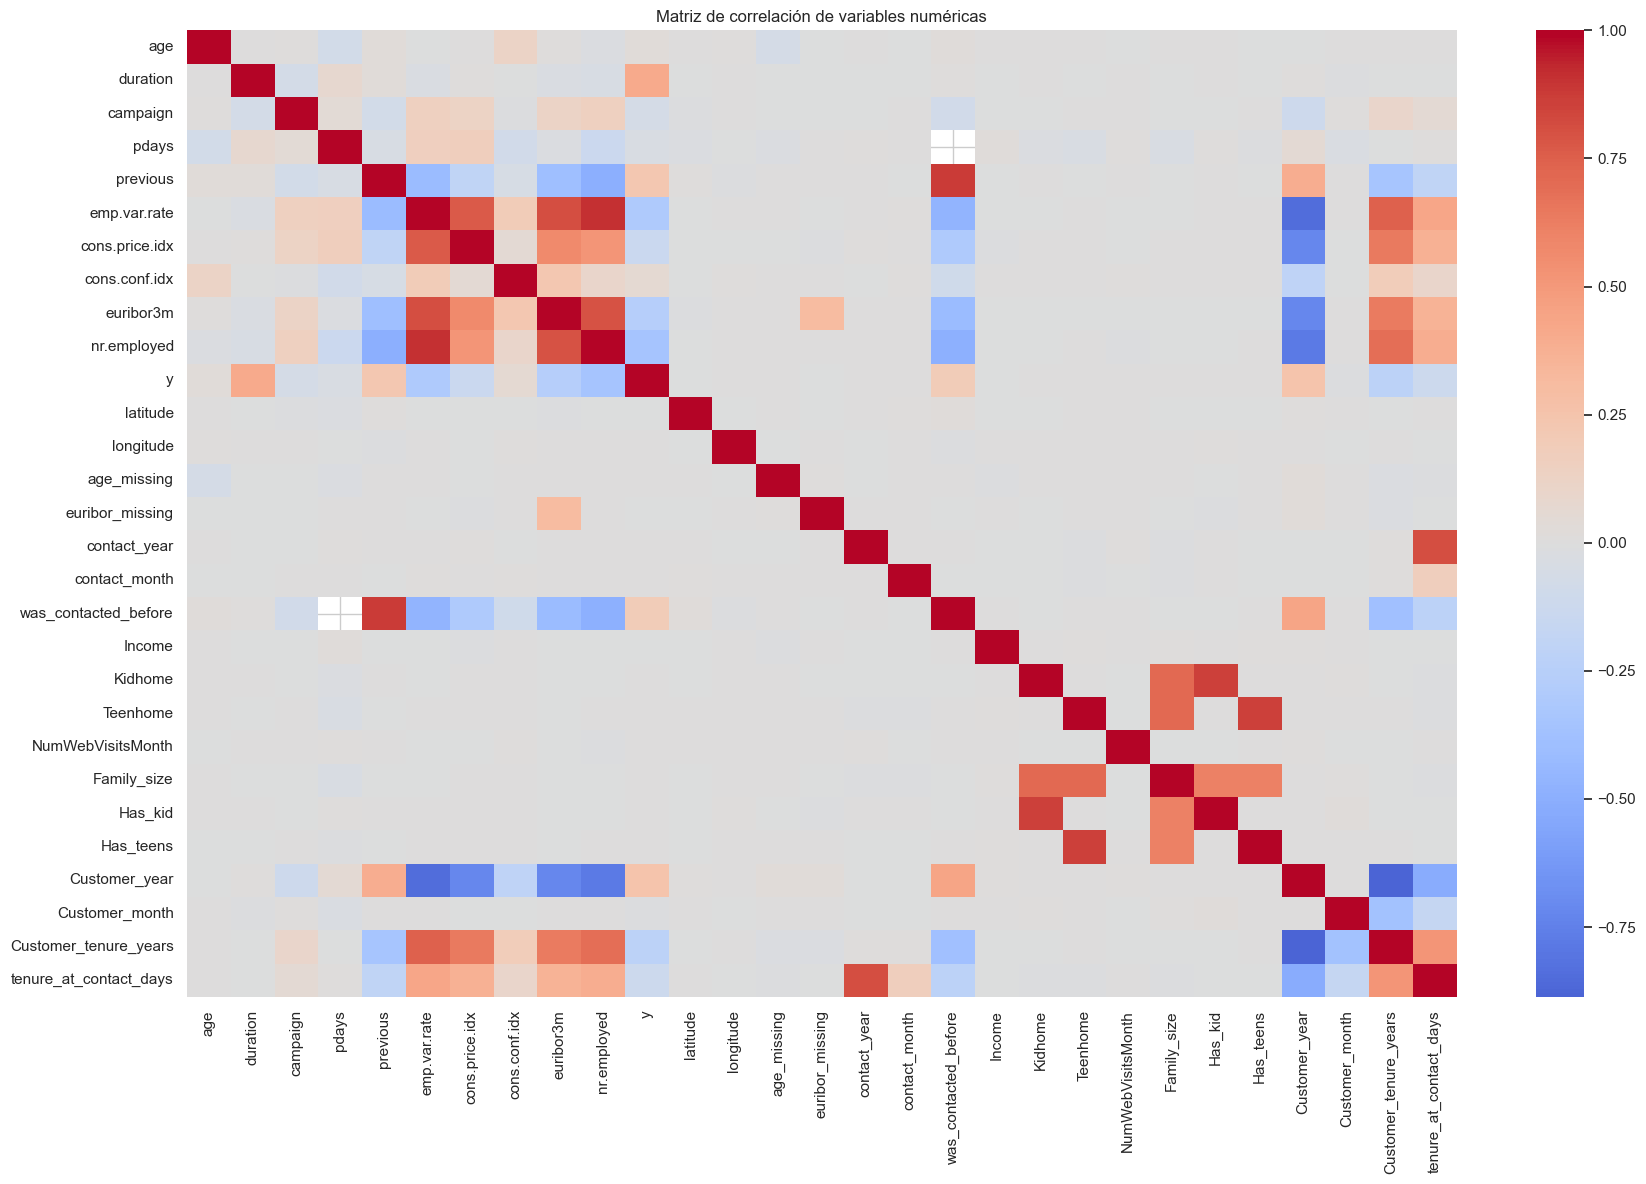

In [95]:
plt.figure(figsize=(18, 12))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()

In [96]:
corr["y"].sort_values(ascending=False)

y                         1.000000
duration                  0.405651
Customer_year             0.249753
previous                  0.232944
was_contacted_before      0.194330
cons.conf.idx             0.057121
age                       0.029627
contact_month             0.004219
contact_year              0.002706
longitude                 0.001876
age_missing               0.000353
Kidhome                   0.000154
NumWebVisitsMonth         0.000020
Family_size              -0.000236
Teenhome                 -0.000488
Has_kid                  -0.001877
Has_teens                -0.001931
Income                   -0.003984
euribor_missing          -0.007058
latitude                 -0.007318
Customer_month           -0.015481
pdays                    -0.033989
campaign                 -0.066304
tenure_at_contact_days   -0.121571
cons.price.idx           -0.135126
Customer_tenure_years    -0.217584
euribor3m                -0.265106
emp.var.rate             -0.298201
nr.employed         

---

14. Conslusiones finales 



- La suscripción del depósito es claramente minoritaria, lo que confirma que la variable objetivo se encuentra desbalanceada.

- Las variables más relacionadas con la conversión parecen estar vinculadas a la interacción comercial, especialmente la duración de la llamada y el historial de contacto previo.

- El resultado de campañas anteriores y el hecho de haber sido contactado previamente muestran una asociación relevante con la probabilidad de suscripción.

- El canal de contacto también presenta diferencias apreciables, lo que sugiere distinta eficacia según la vía utilizada para contactar al cliente.

- El contexto económico parece desempeñar un papel complementario en la explicación de la conversión.

- Las variables sociodemográficas ayudan a perfilar al cliente, aunque en general parecen tener un peso menor que las variables relacionadas con el comportamiento y la campaña.

En definitiva, contestando a la pregunta principal del análisis, podemos decir que: 

Los clientes que sí contratan el depósito suelen tener llamadas más largas con el banco y haber sido contactados anteriormente en campañas previas. También se observan diferencias según el canal de contacto, siendo el móvil más efectivo. En cambio, las características personales del cliente (edad, trabajo o educación) no parecen influir tanto en la decisión de contratar el depósito

---

15. ranking de variables más relacionadas con y

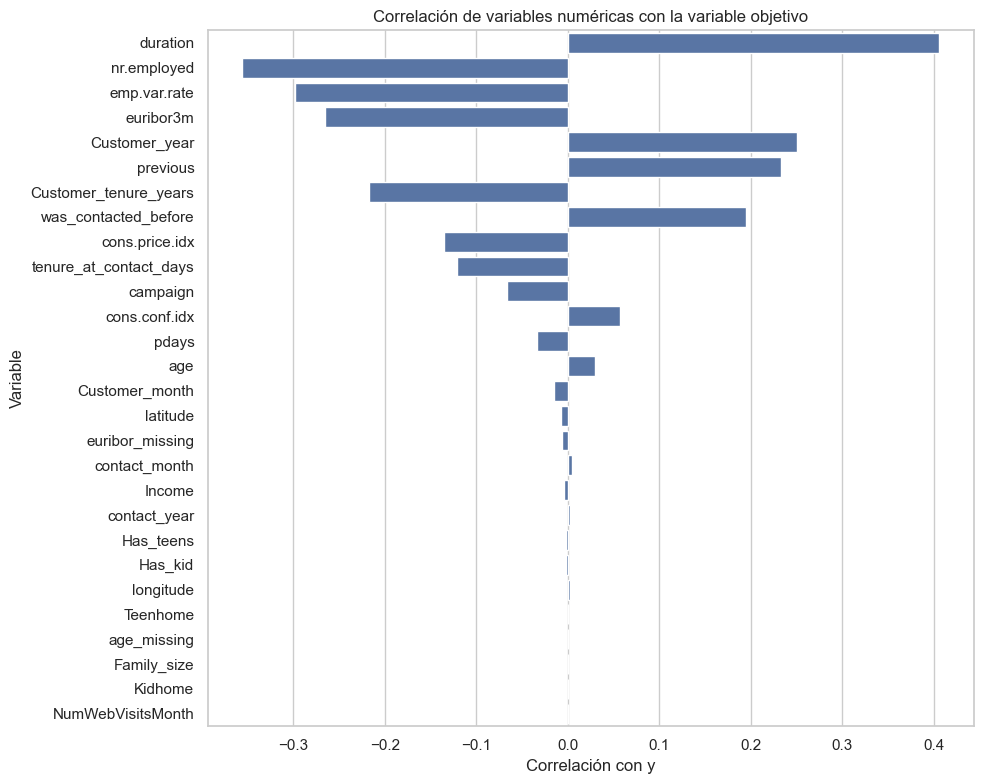

duration                  0.405651
nr.employed              -0.355707
emp.var.rate             -0.298201
euribor3m                -0.265106
Customer_year             0.249753
previous                  0.232944
Customer_tenure_years    -0.217584
was_contacted_before      0.194330
cons.price.idx           -0.135126
tenure_at_contact_days   -0.121571
campaign                 -0.066304
cons.conf.idx             0.057121
pdays                    -0.033989
age                       0.029627
Customer_month           -0.015481
latitude                 -0.007318
euribor_missing          -0.007058
contact_month             0.004219
Income                   -0.003984
contact_year              0.002706
Has_teens                -0.001931
Has_kid                  -0.001877
longitude                 0.001876
Teenhome                 -0.000488
age_missing               0.000353
Family_size              -0.000236
Kidhome                   0.000154
NumWebVisitsMonth         0.000020
Name: y, dtype: floa

In [97]:
corr_with_target = corr["y"].drop("y").sort_values(key=lambda x: abs(x), ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index)
plt.title("Correlación de variables numéricas con la variable objetivo")
plt.xlabel("Correlación con y")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

corr_with_target

16. Automatización con POO

In [98]:
class BankMarketingEDA:
    """
    Clase para realizar un análisis exploratorio básico del dataset de marketing bancario.
    """

    def __init__(self, file_path: str):
        self.file_path = file_path
        self.data = None

    def load_data(self):
        """
        Carga el dataset con control de errores.
        """
        try:
            self.data = pd.read_csv(self.file_path)

            if self.data.empty:
                raise ValueError("El archivo CSV está vacío.")

            print("Dataset cargado correctamente.")
            print(f"Filas: {self.data.shape[0]}")
            print(f"Columnas: {self.data.shape[1]}")

        except FileNotFoundError:
            print(f"Error: no se encontró el archivo '{self.file_path}'.")

        except pd.errors.EmptyDataError:
            print("Error: el archivo está vacío o no contiene datos válidos.")

        except pd.errors.ParserError:
            print("Error: hubo un problema al interpretar el archivo CSV.")

        except Exception as e:
            print(f"Error inesperado al cargar los datos: {e}")

    def show_head(self, n=5):
        """
        Muestra las primeras filas del dataset.
        """
        try:
            if self.data is None:
                raise ValueError("Primero debes cargar los datos con load_data().")

            display(self.data.head(n))

        except Exception as e:
            print(f"Error al mostrar las primeras filas: {e}")

    def general_info(self):
        """
        Muestra información general del dataset.
        """
        try:
            if self.data is None:
                raise ValueError("Los datos no están cargados.")

            print("Información general del dataset")
            print("-" * 50)
            print(f"Dimensiones: {self.data.shape}")
            print("\nTipos de datos:")
            print(self.data.dtypes.value_counts())
            print("\nInformación detallada:")
            display(self.data.info())

        except Exception as e:
            print(f"Error al obtener la información general: {e}")

    def descriptive_stats(self):
        """
        Muestra estadísticas descriptivas de variables numéricas y categóricas.
        """
        try:
            if self.data is None:
                raise ValueError("Los datos no están cargados.")

            print("Estadísticas descriptivas - variables numéricas")
            display(self.data.describe().T)

            print("Estadísticas descriptivas - variables categóricas")
            display(self.data.describe(include="object").T)

        except Exception as e:
            print(f"Error al calcular estadísticas descriptivas: {e}")

    def missing_values(self):
        """
        Muestra resumen de valores nulos.
        """
        try:
            if self.data is None:
                raise ValueError("Los datos no están cargados.")

            missing_summary = pd.DataFrame({
                "missing_values": self.data.isna().sum(),
                "missing_pct": (self.data.isna().sum() / len(self.data) * 100).round(2)
            }).sort_values(by="missing_values", ascending=False)

            print("Resumen de valores nulos")
            display(missing_summary[missing_summary["missing_values"] > 0])

        except Exception as e:
            print(f"Error al analizar valores nulos: {e}")

    def target_distribution(self, target_col="y"):
        """
        Analiza la distribución de la variable objetivo.
        """
        try:
            if self.data is None:
                raise ValueError("Los datos no están cargados.")

            if target_col not in self.data.columns:
                raise KeyError(f"La columna '{target_col}' no existe en el dataset.")

            print("Distribución de la variable objetivo")
            display(self.data[target_col].value_counts())
            display((self.data[target_col].value_counts(normalize=True) * 100).round(2))

            plt.figure(figsize=(7, 5))
            sns.countplot(data=self.data, x=target_col)
            plt.title("Distribución de la variable objetivo")
            plt.xlabel(target_col)
            plt.ylabel("Frecuencia")
            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"Error al analizar la variable objetivo: {e}")

    def numeric_summary_by_target(self, col, target_col="y"):
        """
        Resume una variable numérica agrupada por la variable objetivo.
        """
        try:
            if self.data is None:
                raise ValueError("Los datos no están cargados.")

            if col not in self.data.columns:
                raise KeyError(f"La columna '{col}' no existe.")

            summary = self.data.groupby(target_col)[col].agg(
                ["mean", "median", "std", "min", "max"]
            ).round(2)

            print(f"Resumen de '{col}' según '{target_col}'")
            display(summary)

        except Exception as e:
            print(f"Error al resumir la variable '{col}': {e}")

    def plot_histogram(self, col, bins=30):
        """
        Genera histograma de una variable numérica.
        """
        try:
            if self.data is None:
                raise ValueError("Los datos no están cargados.")

            if col not in self.data.columns:
                raise KeyError(f"La columna '{col}' no existe.")

            plt.figure(figsize=(10, 5))
            sns.histplot(self.data[col].dropna(), bins=bins, kde=True)
            plt.title(f"Distribución de {col}")
            plt.xlabel(col)
            plt.ylabel("Frecuencia")
            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"Error al graficar el histograma de '{col}': {e}")

    def plot_boxplot_by_target(self, col, target_col="y"):
        """
        Genera boxplot de una variable numérica según la variable objetivo.
        """
        try:
            if self.data is None:
                raise ValueError("Los datos no están cargados.")

            if col not in self.data.columns:
                raise KeyError(f"La columna '{col}' no existe.")

            plt.figure(figsize=(8, 5))
            sns.boxplot(data=self.data, x=target_col, y=col)
            plt.title(f"{col} según {target_col}")
            plt.xlabel(target_col)
            plt.ylabel(col)
            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"Error al graficar el boxplot de '{col}': {e}")

    def categorical_target_rate(self, col, target_col="y"):
        """
        Calcula la tasa de conversión por variable categórica.
        """
        try:
            if self.data is None:
                raise ValueError("Los datos no están cargados.")

            if col not in self.data.columns:
                raise KeyError(f"La columna '{col}' no existe.")

            rate_table = pd.crosstab(
                self.data[col],
                self.data[target_col],
                normalize="index"
            ).round(4)

            if 1 in rate_table.columns:
                rate_table["conversion_rate"] = rate_table[1]

            print(f"Tasa de suscripción por '{col}'")
            display(rate_table.sort_values("conversion_rate", ascending=False))

        except Exception as e:
            print(f"Error al calcular la tasa de conversión de '{col}': {e}")

    def correlation_with_target(self, target_col="y"):
        """
        Calcula correlaciones de variables numéricas con la variable objetivo.
        """
        try:
            if self.data is None:
                raise ValueError("Los datos no están cargados.")

            numeric_cols = self.data.select_dtypes(include=["int64", "float64"]).columns

            if target_col not in numeric_cols:
                raise ValueError(f"La columna '{target_col}' debe ser numérica para calcular correlaciones.")

            corr = self.data[numeric_cols].corr()[target_col].sort_values(ascending=False)

            print("Correlación de variables numéricas con la variable objetivo")
            display(corr)

            plt.figure(figsize=(10, 8))
            sns.barplot(x=corr.values, y=corr.index)
            plt.title(f"Correlación con {target_col}")
            plt.xlabel("Correlación")
            plt.ylabel("Variable")
            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"Error al calcular correlaciones: {e}")

In [99]:
eda = BankMarketingEDA("C:/Users/patri/OneDrive/Documentos/Proyecto-EDA/data/processed/bank_marketing.csv")

In [100]:
eda.load_data()

Dataset cargado correctamente.
Filas: 42752
Columnas: 41


In [101]:
eda.show_head()

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_,age_missing,euribor_missing,contact_year,contact_month,contact_weekday,was_contacted_before,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,Family_size,Has_kid,Has_teens,Customer_year,Customer_month,Customer_tenure_years,tenure_at_contact_days
0,38.0,housemaid,married,basic.4y,0.0,0.0,0.0,telephone,261,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,2019-08-02,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,1,0,2019.0,8.0,Friday,0,161770,1,0,2012-04-04,29,1,1,0,2012,4,14.0,7.0
1,57.0,services,married,high.school,unknown,0.0,0.0,telephone,149,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,2016-09-14,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,0,1,2016.0,9.0,Wednesday,0,85477,1,1,2012-12-30,7,2,1,1,2012,12,13.0,4.0
2,37.0,services,married,high.school,0.0,1.0,0.0,telephone,226,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,2019-02-15,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b,0,0,2019.0,2.0,Friday,0,147233,1,1,2012-02-02,5,2,1,1,2012,2,14.0,7.0
3,40.0,admin.,married,basic.6y,0.0,0.0,0.0,telephone,151,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,2015-11-29,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e,0,1,2015.0,11.0,Sunday,0,121393,1,2,2012-12-21,29,3,1,1,2012,12,13.0,3.0
4,56.0,services,married,high.school,0.0,0.0,1.0,telephone,307,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,2017-01-29,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,0,1,2017.0,1.0,Sunday,0,63164,1,2,2012-06-20,20,3,1,1,2012,6,14.0,5.0


In [102]:
eda.descriptive_stats()

Estadísticas descriptivas - variables numéricas


,count,mean,std,min,25%,50%,75%,max
age,42752.0,39.745018,9.822489,17.000,33.000,38.000,46.000,98.000
duration,42752.0,257.766186,258.778698,0.000,102.000,179.000,319.000,4918.000
campaign,42752.0,2.566383,2.770606,1.000,1.000,2.000,3.000,56.000
pdays,1577.0,6.076728,3.873943,0.000,3.000,6.000,7.000,27.000
previous,42752.0,0.174237,0.497828,0.000,0.000,0.000,0.000,7.000
emp.var.rate,42752.0,0.077330,1.573703,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,42752.0,93.576226,0.576815,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,42752.0,-40.510100,4.637412,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,42752.0,3.883822,1.620777,0.634,1.479,4.857,4.959,5.045
nr.employed,42752.0,5166.866537,72.392792,4963.600,5099.100,5191.000,5228.100,5228.100


Estadísticas descriptivas - variables categóricas


C:\Users\patri\AppData\Local\Temp\ipykernel_4896\3818205701.py:80: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(self.data.describe(include="object").T)


,count,unique,top,freq
job,42752,12,admin.,10802
marital,42752,4,married,25840
education,42752,8,university.degree,12642
default,42752,3,0.0,33810
housing,42752,3,1.0,22367
loan,42752,3,0.0,35244
contact,42752,2,cellular,27232
poutcome,42752,3,nonexistent,36883
date,42752,1825,2018-02-28,95
id_,42752,42752,089b39d8-e4d0-461b-87d4-814d71e0e079,1
